In [1]:
import torch
import gpytorch
import pandas as pd
import pickle
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from torch.utils.data import TensorDataset, DataLoader
from pyproj import Transformer
from sklearn.metrics import pairwise_distances
from scipy.interpolate import RegularGridInterpolator
from torch_geometric.data import Data




/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

with open("analysis_dataset_enriched.p", "rb") as f:
  df_processed_enriched = pickle.load(f)

In [3]:
PURPLEAIR_API_KEY = "35F2A02C-D815-11EF-A3B4-42010A800010"

In [20]:
#10 year pull of data. 

import time
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import requests
from dateutil.relativedelta import relativedelta

# ------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------
NWLAT, NWLNG = 38.6, 124.6   # Northwest corner
SELAT, SELNG = 33.0, 131.0   # Southeast corner

END_DATE = datetime.now()
PULL_YEARS = 10
START_DATE = END_DATE - relativedelta(years=PULL_YEARS)

CHUNK_DAYS = 90
BASE_URL = "https://api.purpleair.com/v1"
HEADERS = {"X-API-Key": PURPLEAIR_API_KEY}

SENSOR_METADATA_PATH = "sensor_metadata_full10yr.csv"
RAW_OUT_PATH = "purpleair_raw_full10yr.csv"
WEATHER_OUT_PATH = "weather_by_sensor_full10yr.csv"
MERGED_OUT_PATH = "purpleair_weather_by_sensor_full10yr.csv"


# ------------------------------------------------------------------
# PurpleAir: find every sensor in the bounding box (not pre-filtered)
# ------------------------------------------------------------------
def get_sensors_in_bbox():
    url = f"{BASE_URL}/sensors"
    params = {
        "fields": "sensor_index,name,latitude,longitude,altitude,location_type",
        "nwlat": NWLAT, "nwlng": NWLNG, "selat": SELAT, "selng": SELNG,
        "location_type": 0,          # 0 = outside sensors only
        "max_age": 315360000,        # active in the last 10 years
    }
    r = requests.get(url, headers=HEADERS, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()
    return pd.DataFrame(data["data"], columns=data["fields"])


# ------------------------------------------------------------------
# PurpleAir: pull daily-averaged history for one sensor
# ------------------------------------------------------------------
def get_sensor_history(sensor_index, start_date, end_date):
    url = f"{BASE_URL}/sensors/{sensor_index}/history"
    fields = "pm2.5_atm,pm2.5_cf_1,humidity,temperature,pressure"
    rows = []
    cur = start_date
    while cur < end_date:
        nxt = min(cur + timedelta(days=CHUNK_DAYS), end_date)
        params = {
            "start_timestamp": int(cur.timestamp()),
            "end_timestamp": int(nxt.timestamp()),
            "average": 1440,
            "fields": fields,
        }
        try:
            r = requests.get(url, headers=HEADERS, params=params, timeout=30)
            r.raise_for_status()
            data = r.json()
            if data.get("data"):
                chunk = pd.DataFrame(data["data"], columns=data["fields"])
                chunk["sensor_index"] = sensor_index
                rows.append(chunk)
        except requests.exceptions.HTTPError as e:
            print(f"  sensor {sensor_index}: HTTP error {e}")
        except requests.exceptions.RequestException as e:
            print(f"  sensor {sensor_index}: request failed {e}")
        cur = nxt
        time.sleep(1)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def pull_all_purpleair_data(start_date, end_date):
    """Pulls history for every sensor in the bbox, saving incrementally
    per-sensor -- a ~170-sensor x 10-year pull can take hours, so a crash
    partway through must not lose everything already fetched."""
    sensors = get_sensors_in_bbox()
    print(f"Found {len(sensors)} sensors in bounding box")
    sensors.to_csv(SENSOR_METADATA_PATH, index=False)

    already_done = set()
    if Path(RAW_OUT_PATH).exists():
        existing = pd.read_csv(RAW_OUT_PATH)
        already_done = set(existing["sensor_index"].unique())
        print(f"Resuming: {len(already_done)} sensors already pulled.")

    for _, row in sensors.iterrows():
        if row["sensor_index"] in already_done:
            continue
        print(f"Pulling sensor {row['sensor_index']} ({row['name']})...")
        hist = get_sensor_history(row["sensor_index"], start_date, end_date)
        if hist.empty:
            continue
        hist["date"] = pd.to_datetime(hist["time_stamp"], unit="s").dt.date
        hist["pm25_epa_corrected"] = (
            0.52 * hist["pm2.5_cf_1"] - 0.086 * hist["humidity"] + 5.75
        ).clip(lower=0)
        hist.to_csv(
            RAW_OUT_PATH, mode="a", header=not Path(RAW_OUT_PATH).exists(), index=False
        )

    pa_df = pd.read_csv(RAW_OUT_PATH) if Path(RAW_OUT_PATH).exists() else pd.DataFrame()
    return sensors, pa_df


# ------------------------------------------------------------------
# Open-Meteo: historical weather (unchanged from before)
# ------------------------------------------------------------------
def get_openmeteo_weather(lat, lon, start_date, end_date, max_retries=6):
    url = "https://archive-api.open-meteo.com/v1/archive"
    daily_vars = [
        "temperature_2m_max", "temperature_2m_min", "temperature_2m_mean",
        "relative_humidity_2m_mean", "precipitation_sum", "windgusts_10m_max",
        "surface_pressure_mean", "et0_fao_evapotranspiration",
    ]
    params = {
        "latitude": lat, "longitude": lon,
        "start_date": start_date.strftime("%Y-%m-%d"),
        "end_date": end_date.strftime("%Y-%m-%d"),
        "daily": ",".join(daily_vars),
        "hourly": "windspeed_10m,winddirection_10m",
        "timezone": "auto",
    }
    delay = 5.0
    for attempt in range(max_retries):
        r = requests.get(url, params=params, timeout=30)
        if r.status_code == 429:
            retry_after = r.headers.get("Retry-After")
            wait = float(retry_after) if retry_after else delay
            print(f"    rate limited (429) — waiting {wait:.0f}s (attempt {attempt + 1}/{max_retries})")
            time.sleep(wait)
            delay = min(delay * 2, 120)
            continue
        r.raise_for_status()
        data = r.json()
        daily_df = pd.DataFrame(data["daily"])
        daily_df["date"] = pd.to_datetime(daily_df["time"]).dt.date
        daily_df = daily_df.drop(columns=["time"])
        wind_df = compute_daily_wind_vector(data["hourly"])
        return daily_df.merge(wind_df, on="date", how="left")
    raise RuntimeError(f"Open-Meteo rate limit persisted after {max_retries} retries for ({lat}, {lon})")


def compute_daily_wind_vector(hourly):
    df = pd.DataFrame({
        "time": pd.to_datetime(hourly["time"]),
        "speed": hourly["windspeed_10m"],
        "direction": hourly["winddirection_10m"],
    })
    df["date"] = df["time"].dt.date
    rad = np.radians(df["direction"])
    df["u"] = -df["speed"] * np.sin(rad)
    df["v"] = -df["speed"] * np.cos(rad)
    daily = df.groupby("date").agg(u_mean=("u", "mean"), v_mean=("v", "mean")).reset_index()
    daily["windspeed_10m_mean"] = np.sqrt(daily["u_mean"] ** 2 + daily["v_mean"] ** 2)
    daily["winddirection_10m_prevailing"] = (
        np.degrees(np.arctan2(-daily["u_mean"], -daily["v_mean"])) % 360
    )
    return daily[["date", "windspeed_10m_mean", "winddirection_10m_prevailing"]]


_weather_cache = {}


def get_weather_for_sensor(lat, lon, start_date, end_date, round_dp=1):
    key = (round(lat, round_dp), round(lon, round_dp))
    if key not in _weather_cache:
        w = get_openmeteo_weather(key[0], key[1], start_date, end_date)
        _weather_cache[key] = w
        time.sleep(2.0)
    return _weather_cache[key]


# ------------------------------------------------------------------
# Main
# ------------------------------------------------------------------
def main():
    print(f"Pulling ALL sensors in bbox, {START_DATE.date()} to {END_DATE.date()} ({PULL_YEARS} years)")
    sensors, pa_df = pull_all_purpleair_data(START_DATE, END_DATE)
    if pa_df.empty:
        print("No PurpleAir data returned — check your API key and bbox.")
        return

    sensor_locs = sensors[["sensor_index", "latitude", "longitude"]]

    already_done = set()
    if Path(WEATHER_OUT_PATH).exists():
        existing = pd.read_csv(WEATHER_OUT_PATH)
        already_done = set(existing["sensor_index"].unique())
        print(f"Resuming weather: {len(already_done)} sensors already saved.")

    failed_sensors = []
    for sensor_index, lat, lon in sensor_locs.itertuples(index=False):
        if sensor_index in already_done:
            continue
        print(f"Fetching weather for sensor {sensor_index} ({lat}, {lon})...")
        try:
            w = get_weather_for_sensor(lat, lon, START_DATE, END_DATE)
        except Exception as e:
            print(f"  giving up on sensor {sensor_index}: {e}")
            failed_sensors.append(sensor_index)
            continue
        w = w.copy()
        w["sensor_index"] = sensor_index
        w.to_csv(WEATHER_OUT_PATH, mode="a", header=not Path(WEATHER_OUT_PATH).exists(), index=False)

    weather_by_sensor = pd.read_csv(WEATHER_OUT_PATH)
    print(f"Saved {len(weather_by_sensor)} sensor-days of weather.")
    if failed_sensors:
        print(f"WARNING: {len(failed_sensors)} sensors failed weather retrieval: {failed_sensors}")

    per_sensor = pa_df.merge(sensor_locs, on="sensor_index", how="left")
    per_sensor = per_sensor.merge(weather_by_sensor, on=["sensor_index", "date"], how="left")
    per_sensor.to_csv(MERGED_OUT_PATH, index=False)
    print(f"Saved {len(per_sensor)} rows to {MERGED_OUT_PATH}")


if __name__ == "__main__":
    main()


Pulling ALL sensors in bbox, 2016-08-19 to 2026-08-19 (10 years)
Found 192 sensors in bounding box
Pulling sensor 263837 (영남대학교 기계관 E29동)...
Pulling sensor 2394 (Yongsan-gu, Seoul)...
Pulling sensor 5302 (SCH Test2)...
Pulling sensor 5314 (dj05_OUT)...
Pulling sensor 5330 (신창면행정복지센터)...
Pulling sensor 5390 (A74D)...
Pulling sensor 5392 (sch_A4)...
Pulling sensor 5406 (sc03_04_out)...
Pulling sensor 269317 (U.S. Village)...
Pulling sensor 10046 (mob_outside)...
Pulling sensor 10060 (Air-Safety Cafe 1st_outside)...
Pulling sensor 15081 (WhiteVilla_Out)...
Pulling sensor 15087 (Air-Safety Bunker 1st_outside)...
Pulling sensor 281396 (NASA_AERONET_Hankuk_UFS)...
Pulling sensor 23369 (gcfarm)...
Pulling sensor 27899 (HeungDuk)...
Pulling sensor 28949 (Air Safety House_namyeon_outside)...
Pulling sensor 29745 (sc01_1_out)...
Pulling sensor 29747 (화덕보건진료소)...
Pulling sensor 29749 (br08_out)...
Pulling sensor 30025 (SCH Test5)...
Pulling sensor 30295 (outsidepoit)...
Pulling sensor 30309 (KH_3

KeyboardInterrupt: 

In [38]:
#open meteo pull
import time
from pathlib import Path

import numpy as np
import pandas as pd
import requests

# ------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------
SENSOR_METADATA_PATH = "sensor_metadata_full10yr.csv"
RAW_PATH = "purpleair_raw_full10yr.csv"
WEATHER_OUT_PATH = "weather_by_sensor_full10yr.csv"

# Sensor list comes from what you already pulled -- no PurpleAir API calls needed
sensors = pd.read_csv(SENSOR_METADATA_PATH)
sensor_locs = sensors[["sensor_index", "latitude", "longitude"]].drop_duplicates("sensor_index")

# Derive the exact date range from the PM2.5 data you already collected,
# rather than recomputing "10 years back from right now" -- this guarantees
# the weather pull lines up exactly with what's actually in your PM2.5 data,
# regardless of when that pull was run relative to today.
pa_time = pd.read_csv(RAW_PATH, usecols=["time_stamp"])
pa_dates = pd.to_datetime(pa_time["time_stamp"], unit="s")
START_DATE = pa_dates.min()
END_DATE = pa_dates.max()
print(f"Weather pull will span {START_DATE.date()} to {END_DATE.date()} "
      f"(matching the PM2.5 data already in {RAW_PATH})")
print(f"{len(sensor_locs)} sensors to cover")


# ------------------------------------------------------------------
# Open-Meteo: historical weather (unchanged from before)
# ------------------------------------------------------------------
def get_openmeteo_weather(lat, lon, start_date, end_date, max_retries=6):
    url = "https://archive-api.open-meteo.com/v1/archive"
    daily_vars = [
        "temperature_2m_max", "temperature_2m_min", "temperature_2m_mean",
        "relative_humidity_2m_mean", "precipitation_sum", "windgusts_10m_max",
        "surface_pressure_mean", "et0_fao_evapotranspiration",
    ]
    params = {
        "latitude": lat, "longitude": lon,
        "start_date": start_date.strftime("%Y-%m-%d"),
        "end_date": end_date.strftime("%Y-%m-%d"),
        "daily": ",".join(daily_vars),
        "hourly": "windspeed_10m,winddirection_10m",
        "timezone": "auto",
    }
    delay = 5.0
    last_error = None
    for attempt in range(max_retries):
        try:
            r = requests.get(url, params=params, timeout=30)
        except requests.exceptions.RequestException as e:
            # Network-level failure (timeout, connection reset, DNS, etc.) --
            # previously this propagated immediately with zero retries, since
            # only 429 responses were being retried. Back off and try again
            # instead of giving up on the first transient hiccup.
            last_error = e
            print(f"    network error ({e.__class__.__name__}) — waiting {delay:.0f}s "
                  f"(attempt {attempt + 1}/{max_retries})")
            time.sleep(delay)
            delay = min(delay * 2, 120)
            continue

        if r.status_code == 429:
            retry_after = r.headers.get("Retry-After")
            wait = float(retry_after) if retry_after else delay
            print(f"    rate limited (429) — waiting {wait:.0f}s (attempt {attempt + 1}/{max_retries})")
            time.sleep(wait)
            delay = min(delay * 2, 120)
            continue

        r.raise_for_status()
        data = r.json()
        daily_df = pd.DataFrame(data["daily"])
        daily_df["date"] = pd.to_datetime(daily_df["time"]).dt.date
        daily_df = daily_df.drop(columns=["time"])
        wind_df = compute_daily_wind_vector(data["hourly"])
        return daily_df.merge(wind_df, on="date", how="left")

    raise RuntimeError(
        f"Open-Meteo request failed after {max_retries} retries for ({lat}, {lon}). "
        f"Last error: {last_error}"
    )



def compute_daily_wind_vector(hourly):
    df = pd.DataFrame({
        "time": pd.to_datetime(hourly["time"]),
        "speed": hourly["windspeed_10m"],
        "direction": hourly["winddirection_10m"],
    })
    df["date"] = df["time"].dt.date
    rad = np.radians(df["direction"])
    df["u"] = -df["speed"] * np.sin(rad)
    df["v"] = -df["speed"] * np.cos(rad)
    daily = df.groupby("date").agg(u_mean=("u", "mean"), v_mean=("v", "mean")).reset_index()
    daily["windspeed_10m_mean"] = np.sqrt(daily["u_mean"] ** 2 + daily["v_mean"] ** 2)
    daily["winddirection_10m_prevailing"] = (
        np.degrees(np.arctan2(-daily["u_mean"], -daily["v_mean"])) % 360
    )
    return daily[["date", "windspeed_10m_mean", "winddirection_10m_prevailing"]]


_weather_cache = {}


def get_weather_for_sensor(lat, lon, start_date, end_date, round_dp=1):
    key = (round(lat, round_dp), round(lon, round_dp))
    if key not in _weather_cache:
        w = get_openmeteo_weather(key[0], key[1], start_date, end_date)
        _weather_cache[key] = w
        time.sleep(2.0)
    return _weather_cache[key]


# ------------------------------------------------------------------
# Main: weather-only pull, resuming from whatever's already saved
# ------------------------------------------------------------------
def main():
    already_done = set()
    if Path(WEATHER_OUT_PATH).exists():
        existing = pd.read_csv(WEATHER_OUT_PATH)
        already_done = set(existing["sensor_index"].unique())

    remaining = sensor_locs[~sensor_locs["sensor_index"].isin(already_done)]
    total_remaining = len(remaining)
    print(f"{len(already_done)} of {len(sensor_locs)} sensors already done. "
          f"{total_remaining} remaining to pull.\n")

    failed_sensors = []
    start_time = time.time()
    for i, (sensor_index, lat, lon) in enumerate(remaining.itertuples(index=False), start=1):
        elapsed = time.time() - start_time
        eta_str = ""
        if i > 1:
            avg_per_sensor = elapsed / (i - 1)
            eta_min = avg_per_sensor * (total_remaining - i + 1) / 60
            eta_str = f" | ETA ~{eta_min:.1f} min"
        print(f"[{i}/{total_remaining}] Fetching weather for sensor {sensor_index} "
              f"({lat}, {lon})...{eta_str}")
        try:
            w = get_weather_for_sensor(lat, lon, START_DATE, END_DATE)
        except Exception as e:
            print(f"  giving up on sensor {sensor_index}: {e}")
            failed_sensors.append(sensor_index)
            continue
        w = w.copy()
        w["sensor_index"] = sensor_index
        w.to_csv(WEATHER_OUT_PATH, mode="a", header=not Path(WEATHER_OUT_PATH).exists(), index=False)

    weather_by_sensor = pd.read_csv(WEATHER_OUT_PATH)
    print(f"\nDone. {len(weather_by_sensor)} total sensor-days of weather saved to {WEATHER_OUT_PATH}")
    print(f"{weather_by_sensor['sensor_index'].nunique()} of {len(sensor_locs)} sensors covered.")
    if failed_sensors:
        print(f"WARNING: {len(failed_sensors)} sensors failed this run: {failed_sensors}")
        print("Re-run this cell to retry just the failed ones -- already-successful sensors are skipped automatically.")





if __name__ == "__main__":
    main()


Weather pull will span 2017-07-31 to 2026-08-18 (matching the PM2.5 data already in purpleair_raw_full10yr.csv)
192 sensors to cover
57 of 192 sensors already done. 135 remaining to pull.

[1/135] Fetching weather for sensor 37719 (37.07918, 127.03796)...
    rate limited (429) — waiting 5s (attempt 1/6)
    rate limited (429) — waiting 10s (attempt 2/6)
    rate limited (429) — waiting 20s (attempt 3/6)
    rate limited (429) — waiting 40s (attempt 4/6)
    rate limited (429) — waiting 80s (attempt 5/6)
    rate limited (429) — waiting 120s (attempt 6/6)


KeyboardInterrupt: 

In [ ]:
#second try to get remaining locations open meteo 

In [40]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import requests

SENSOR_METADATA_PATH = "sensor_metadata_full10yr.csv"
RAW_PATH = "purpleair_raw_full10yr.csv"
WEATHER_OUT_PATH = "weather_by_sensor_full10yr.csv"
BATCH_SIZE = 25  # conservative default -- docs don't state a hard cap, adjust down if you get an error

def compute_daily_wind_vector(hourly):
    df = pd.DataFrame({
        "time": pd.to_datetime(hourly["time"]),
        "speed": hourly["windspeed_10m"],
        "direction": hourly["winddirection_10m"],
    })
    df["date"] = df["time"].dt.date
    rad = np.radians(df["direction"])
    df["u"] = -df["speed"] * np.sin(rad)
    df["v"] = -df["speed"] * np.cos(rad)
    daily = df.groupby("date").agg(u_mean=("u", "mean"), v_mean=("v", "mean")).reset_index()
    daily["windspeed_10m_mean"] = np.sqrt(daily["u_mean"] ** 2 + daily["v_mean"] ** 2)
    daily["winddirection_10m_prevailing"] = (
        np.degrees(np.arctan2(-daily["u_mean"], -daily["v_mean"])) % 360
    )
    return daily[["date", "windspeed_10m_mean", "winddirection_10m_prevailing"]]


def get_openmeteo_weather_batch(locations, start_date, end_date, max_retries=6):
    """locations: list of (lat, lon) tuples. Returns dict {(lat, lon): weather_df}."""
    url = "https://archive-api.open-meteo.com/v1/archive"
    daily_vars = [
        "temperature_2m_max", "temperature_2m_min", "temperature_2m_mean",
        "relative_humidity_2m_mean", "precipitation_sum", "windgusts_10m_max",
        "surface_pressure_mean", "et0_fao_evapotranspiration",
    ]
    params = {
        "latitude": ",".join(str(lat) for lat, lon in locations),
        "longitude": ",".join(str(lon) for lat, lon in locations),
        "start_date": start_date.strftime("%Y-%m-%d"),
        "end_date": end_date.strftime("%Y-%m-%d"),
        "daily": ",".join(daily_vars),
        "hourly": "windspeed_10m,winddirection_10m",
        "timezone": "auto",
    }

    delay = 5.0
    last_error = None
    for attempt in range(max_retries):
        try:
            r = requests.get(url, params=params, timeout=60)
        except requests.exceptions.RequestException as e:
            last_error = e
            print(f"    network error ({e.__class__.__name__}) -- waiting {delay:.0f}s "
                  f"(attempt {attempt + 1}/{max_retries})")
            time.sleep(delay)
            delay = min(delay * 2, 120)
            continue

        if r.status_code == 429:
            # Print the actual reason Open-Meteo gives, not just the status code --
            # this tells us whether it's a per-minute, hourly, or daily limit, which
            # determines whether retrying in a few minutes will even help.
            try:
                reason = r.json().get("reason", "(no reason given)")
            except Exception:
                reason = r.text[:200]
            retry_after = r.headers.get("Retry-After")
            wait = float(retry_after) if retry_after else delay
            print(f"    rate limited (429): {reason} -- waiting {wait:.0f}s "
                  f"(attempt {attempt + 1}/{max_retries})")
            last_error = f"429: {reason}"
            time.sleep(wait)
            delay = min(delay * 2, 120)
            continue

        r.raise_for_status()
        data = r.json()

        if not isinstance(data, list):
            raise RuntimeError(
                f"Expected a list response for a {len(locations)}-location batch request, "
                f"got {type(data)} instead: {data}"
            )
        if len(data) != len(locations):
            raise RuntimeError(
                f"Requested {len(locations)} locations but got {len(data)} results back -- "
                f"order/count mismatch, don't trust index-based mapping here."
            )

        results = {}
        for (lat, lon), item in zip(locations, data):
            daily_df = pd.DataFrame(item["daily"])
            daily_df["date"] = pd.to_datetime(daily_df["time"]).dt.date
            daily_df = daily_df.drop(columns=["time"])
            wind_df = compute_daily_wind_vector(item["hourly"])
            results[(lat, lon)] = daily_df.merge(wind_df, on="date", how="left")
        return results

    raise RuntimeError(
        f"Open-Meteo batch request failed after {max_retries} retries "
        f"for {len(locations)} locations. Last error: {last_error}"
    )


def main():
    sensors = pd.read_csv(SENSOR_METADATA_PATH)
    sensor_locs = sensors[["sensor_index", "latitude", "longitude"]].drop_duplicates("sensor_index")

    pa_time = pd.read_csv(RAW_PATH, usecols=["time_stamp"])
    pa_dates = pd.to_datetime(pa_time["time_stamp"], unit="s")
    START_DATE = pa_dates.min()
    END_DATE = pa_dates.max()

    round_dp = 1
    sensor_locs = sensor_locs.copy()
    sensor_locs["round_key"] = list(zip(
        sensor_locs["latitude"].round(round_dp), sensor_locs["longitude"].round(round_dp)
    ))
    unique_locations = sorted(set(sensor_locs["round_key"]))
    print(f"{len(sensor_locs)} sensors -> {len(unique_locations)} unique locations after rounding")

    already_done = set()
    if Path(WEATHER_OUT_PATH).exists():
        existing = pd.read_csv(WEATHER_OUT_PATH)
        already_done = set(existing["sensor_index"].unique())

    remaining_sensors = sensor_locs[~sensor_locs["sensor_index"].isin(already_done)]
    remaining_locations = sorted(set(remaining_sensors["round_key"]))
    n_batches = (len(remaining_locations) + BATCH_SIZE - 1) // BATCH_SIZE
    print(f"{len(already_done)} sensors already done. "
          f"{len(remaining_locations)} unique locations still needed -> {n_batches} batch requests "
          f"(vs. {len(remaining_sensors)} individual calls before batching)")

    weather_cache = {}
    for b in range(n_batches):
        batch = remaining_locations[b * BATCH_SIZE:(b + 1) * BATCH_SIZE]
        print(f"[batch {b + 1}/{n_batches}] fetching {len(batch)} locations...")
        results = get_openmeteo_weather_batch(batch, START_DATE, END_DATE)
        if b == 0:
            first_key = batch[0]
            print(f"  sanity check, first location {first_key}: "
                  f"{len(results[first_key])} days, columns={list(results[first_key].columns)}")
        weather_cache.update(results)
        time.sleep(2.0)

    failed_sensors = []
    for sensor_index, lat, lon, key in remaining_sensors[["sensor_index", "latitude", "longitude", "round_key"]].itertuples(index=False):
        if key not in weather_cache:
            failed_sensors.append(sensor_index)
            continue
        w = weather_cache[key].copy()
        w["sensor_index"] = sensor_index
        w.to_csv(WEATHER_OUT_PATH, mode="a", header=not Path(WEATHER_OUT_PATH).exists(), index=False)

    weather_by_sensor = pd.read_csv(WEATHER_OUT_PATH)
    print(f"\nDone. {len(weather_by_sensor)} total sensor-days saved to {WEATHER_OUT_PATH}")
    print(f"{weather_by_sensor['sensor_index'].nunique()} of {len(sensor_locs)} sensors covered.")
    if failed_sensors:
        print(f"WARNING: {len(failed_sensors)} sensors had no matching batch result: {failed_sensors}")


if __name__ == "__main__":
    main()


192 sensors -> 62 unique locations after rounding
57 sensors already done. 49 unique locations still needed -> 2 batch requests (vs. 135 individual calls before batching)
[batch 1/2] fetching 25 locations...
    rate limited (429): Hourly API request limit exceeded. Please try again in the next hour. -- waiting 5s (attempt 1/6)
    rate limited (429): Hourly API request limit exceeded. Please try again in the next hour. -- waiting 10s (attempt 2/6)
    rate limited (429): Hourly API request limit exceeded. Please try again in the next hour. -- waiting 20s (attempt 3/6)
    rate limited (429): Hourly API request limit exceeded. Please try again in the next hour. -- waiting 40s (attempt 4/6)
    rate limited (429): Hourly API request limit exceeded. Please try again in the next hour. -- waiting 80s (attempt 5/6)


KeyboardInterrupt: 

In [ ]:
import pandas as pd

pa_df = pd.read_csv("purpleair_raw_full10yr.csv")
pa_df["date"] = pd.to_datetime(pa_df["date"]).dt.date

# Not required for the merge (no name collision this time) -- this is purely
# for schema consistency with analysis_dataset_enriched.p, which never carried
# the raw PurpleAir onboard readings or time_stamp/pm2.5_atm/pm2.5_cf_1.
pa_df = pa_df.drop(columns=["time_stamp", "humidity", "temperature", "pressure", "pm2.5_atm", "pm2.5_cf_1"])

sensors = pd.read_csv("sensor_metadata_full10yr.csv")
sensor_locs = sensors[["sensor_index", "latitude", "longitude"]]

weather_by_sensor = pd.read_csv("weather_by_sensor_full10yr.csv")
weather_by_sensor["date"] = pd.to_datetime(weather_by_sensor["date"]).dt.date

per_sensor = pa_df.merge(sensor_locs, on="sensor_index", how="left")
per_sensor = per_sensor.merge(weather_by_sensor, on=["sensor_index", "date"], how="inner")
per_sensor.to_csv("purpleair_weather_by_sensor_full10yr.csv", index=False)

print(f"Saved {len(per_sensor)} rows to purpleair_weather_by_sensor_full10yr.csv")
print(f"columns: {list(per_sensor.columns)}")


In [ ]:
#pm_df=pd.read_csv("purpleair_weather_by_sensor_full10yr.csv")
pm_df=pd.read_csv('purpleair_raw_full10yr.csv')
weather_df=pd.read_csv('weather_by_sensor_full10yr.csv')


#pm_df=pm_df.drop(columns=['time_stamp','humidity','temperature','pressure','pm2.5_atm','pm2.5_cf_1','temperature_2m_max','temperature_2m_min','temperature_2m_mean',
 #                         'relative_humidity_2m_mean','precipitation_sum','windgusts_10m_max','surface_pressure_mean','et0_fao_evapotranspiration','windspeed_10m_mean','winddirection_10m_prevailing'])

pm_df=pm_df.drop(columns=['time_stamp', 'humidity', 'temperature', 'pressure', 'pm2.5_atm',
       'pm2.5_cf_1'])

analysis_df=pd.merge(pm_df,weather_df,on=['sensor_index','date'],how='inner')



In [29]:
analysis_df1.head(10)

,sensor_index,date,pm25_epa_corrected,temperature_2m_max,temperature_2m_min,temperature_2m_mean,relative_humidity_2m_mean,precipitation_sum,windgusts_10m_max,surface_pressure_mean,et0_fao_evapotranspiration,windspeed_10m_mean,winddirection_10m_prevailing
0,263837,2025-03-26,18.666,23.8,7.0,15.0,44,0.0,39.6,998.9,4.53,7.363681,203.933829
1,263837,2025-04-01,24.644,16.2,0.8,7.9,55,0.0,31.0,1015.2,3.54,3.457570,92.385191
2,263837,2025-03-21,19.974,21.3,1.3,11.2,52,0.0,47.5,1005.4,4.13,10.197071,227.347676
3,263837,2025-03-29,15.900,11.5,1.0,5.7,35,0.0,51.1,1013.3,3.63,14.555702,291.574121
4,263837,2025-03-25,21.796,24.4,5.3,15.0,61,0.0,55.1,994.3,4.80,9.828329,221.926467
5,263837,2025-03-20,35.798,15.9,-3.2,6.0,56,0.0,37.8,1012.2,3.21,7.094661,250.086594
6,263837,2025-04-02,19.518,17.2,0.6,8.2,64,5.3,34.6,1011.3,3.45,2.208276,64.068744
7,263837,2025-03-28,22.374,13.3,5.3,9.0,53,2.1,43.6,1004.1,3.36,10.329987,316.341707
8,263837,2025-03-13,13.422,15.7,3.5,8.5,60,0.0,26.6,1013.9,2.55,3.025837,336.488799
9,263837,2025-03-19,41.004,8.0,-3.7,2.1,54,0.0,32.4,1015.5,2.59,8.312713,290.224471


In [5]:
import pickle
import time
from datetime import timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import requests
from dateutil.relativedelta import relativedelta

# ------------------------------------------------------------------
# CONFIG — edit these
# ------------------------------------------------------------------

# Source of truth for which sensors to pull and what date range to backfill.
# We only want history for sensors already in our analysis dataset, and only
# for the years immediately preceding the data we already have.
ANALYSIS_DATASET_PATH = "analysis_dataset_enriched.p"
BACKFILL_YEARS = 7

with open(ANALYSIS_DATASET_PATH, "rb") as f:
    df_processed_enriched = pickle.load(f)
df_processed_enriched["date"] = pd.to_datetime(df_processed_enriched["date"])

existing_min_date = df_processed_enriched["date"].min()

START_DATE = existing_min_date - relativedelta(years=BACKFILL_YEARS)
END_DATE = existing_min_date  # exclusive upper bound -- butts up against existing data, no overlap

KNOWN_SENSOR_INDICES = df_processed_enriched["sensor_index"].drop_duplicates().tolist()

# PurpleAir history endpoint limits how many days you can request per call
# depending on the averaging interval. 1440 (daily average) allows a large
# window, but we chunk conservatively to avoid timeouts/rate limits.
CHUNK_DAYS = 90

BASE_URL = "https://api.purpleair.com/v1"
HEADERS = {"X-API-Key": PURPLEAIR_API_KEY}


# ------------------------------------------------------------------
# PurpleAir: fetch metadata for exactly the known sensors (not a bbox search)
# ------------------------------------------------------------------
def get_sensors_by_index(sensor_indices):
    url = f"{BASE_URL}/sensors"
    params = {
        "fields": "sensor_index,name,latitude,longitude,altitude,location_type",
        "show_only": ",".join(str(s) for s in sensor_indices),  # restrict to our known network
        "location_type": 0,          # 0 = outside sensors only (skip indoor units)
        "max_age": 315360000,        # Active in the last 10 years (10 years in seconds)
    }
    r = requests.get(url, headers=HEADERS, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()
    return pd.DataFrame(data["data"], columns=data["fields"])


# ------------------------------------------------------------------
# PurpleAir: pull daily-averaged history for one sensor
# ------------------------------------------------------------------
def get_sensor_history(sensor_index, start_date, end_date):
    url = f"{BASE_URL}/sensors/{sensor_index}/history"
    fields = "pm2.5_atm,pm2.5_cf_1,humidity,temperature,pressure"
    rows = []

    cur = start_date
    while cur < end_date:
        nxt = min(cur + timedelta(days=CHUNK_DAYS), end_date)
        params = {
            "start_timestamp": int(cur.timestamp()),
            "end_timestamp": int(nxt.timestamp()),
            "average": 1440,  # 1440 minutes = daily average
            "fields": fields,
        }
        try:
            r = requests.get(url, headers=HEADERS, params=params, timeout=30)
            r.raise_for_status()
            data = r.json()
            if data.get("data"):
                chunk = pd.DataFrame(data["data"], columns=data["fields"])
                chunk["sensor_index"] = sensor_index
                rows.append(chunk)
        except requests.exceptions.HTTPError as e:
            print(f"  sensor {sensor_index}: HTTP error {e}")
        except requests.exceptions.RequestException as e:
            print(f"  sensor {sensor_index}: request failed {e}")
        cur = nxt
        time.sleep(1)  # stay well under PurpleAir's rate limit

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def pull_all_purpleair_data(sensor_indices, start_date, end_date):
    """Returns (sensor_metadata_df, history_df), same structure as the
    original bbox-based version, but restricted to sensor_indices -- exactly
    the sensors already present in df_processed_enriched."""
    sensors = get_sensors_by_index(sensor_indices)
    print(f"Found {len(sensors)} of {len(sensor_indices)} known sensors still queryable via PurpleAir")

    all_hist = []
    for _, row in sensors.iterrows():
        print(f"Pulling sensor {row['sensor_index']} ({row['name']})...")
        hist = get_sensor_history(row["sensor_index"], start_date, end_date)
        if not hist.empty:
            all_hist.append(hist)

    if not all_hist:
        return sensors, pd.DataFrame()

    df = pd.concat(all_hist, ignore_index=True)
    df["date"] = pd.to_datetime(df["time_stamp"], unit="s").dt.date

    # Basic EPA-style humidity correction for PM2.5
    df["pm25_epa_corrected"] = (
        0.52 * df["pm2.5_cf_1"] - 0.086 * df["humidity"] + 5.75
    ).clip(lower=0)

    return sensors, df


# ------------------------------------------------------------------
# Open-Meteo: historical weather for the bbox (no API key needed)
# ------------------------------------------------------------------
def get_openmeteo_weather(lat, lon, start_date, end_date, max_retries=6):
    """
    Daily temperature/humidity/precipitation/pressure/ET0 come straight from
    Open-Meteo's daily aggregates. Wind direction and speed are computed
    using vector components.
    """
    url = "https://archive-api.open-meteo.com/v1/archive"
    daily_vars = [
        "temperature_2m_max",
        "temperature_2m_min",
        "temperature_2m_mean",
        "relative_humidity_2m_mean",
        "precipitation_sum",
        "windgusts_10m_max",
        "surface_pressure_mean",
        "et0_fao_evapotranspiration",
    ]
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date.strftime("%Y-%m-%d"),
        "end_date": end_date.strftime("%Y-%m-%d"),
        "daily": ",".join(daily_vars),
        "hourly": "windspeed_10m,winddirection_10m",
        "timezone": "auto",
    }

    delay = 5.0
    for attempt in range(max_retries):
        r = requests.get(url, params=params, timeout=30)
        if r.status_code == 429:
            retry_after = r.headers.get("Retry-After")
            wait = float(retry_after) if retry_after else delay
            print(f"    rate limited (429) — waiting {wait:.0f}s "
                  f"(attempt {attempt + 1}/{max_retries})")
            time.sleep(wait)
            delay = min(delay * 2, 120)
            continue
        r.raise_for_status()
        data = r.json()

        daily_df = pd.DataFrame(data["daily"])
        daily_df["date"] = pd.to_datetime(daily_df["time"]).dt.date
        daily_df = daily_df.drop(columns=["time"])

        wind_df = compute_daily_wind_vector(data["hourly"])
        return daily_df.merge(wind_df, on="date", how="left")

    raise RuntimeError(f"Open-Meteo rate limit persisted after {max_retries} retries "
                        f"for ({lat}, {lon})")


def compute_daily_wind_vector(hourly):
    df = pd.DataFrame({
        "time": pd.to_datetime(hourly["time"]),
        "speed": hourly["windspeed_10m"],
        "direction": hourly["winddirection_10m"],
    })
    df["date"] = df["time"].dt.date

    rad = np.radians(df["direction"])
    df["u"] = -df["speed"] * np.sin(rad)
    df["v"] = -df["speed"] * np.cos(rad)

    daily = df.groupby("date").agg(u_mean=("u", "mean"), v_mean=("v", "mean")).reset_index()

    daily["windspeed_10m_mean"] = np.sqrt(daily["u_mean"] ** 2 + daily["v_mean"] ** 2)
    daily["winddirection_10m_prevailing"] = (
        np.degrees(np.arctan2(-daily["u_mean"], -daily["v_mean"])) % 360
    )

    return daily[["date", "windspeed_10m_mean", "winddirection_10m_prevailing"]]


_weather_cache = {}


def get_weather_for_sensor(lat, lon, start_date, end_date, round_dp=1):
    key = (round(lat, round_dp), round(lon, round_dp))
    if key not in _weather_cache:
        w = get_openmeteo_weather(key[0], key[1], start_date, end_date)
        _weather_cache[key] = w
        time.sleep(2.0)
    return _weather_cache[key]


# ------------------------------------------------------------------
# Main
# ------------------------------------------------------------------
def main():
    print(f"Backfilling {len(KNOWN_SENSOR_INDICES)} known sensors from "
          f"{START_DATE.date()} to {END_DATE.date()} ({BACKFILL_YEARS} years before existing data)")

    sensors, pa_df = pull_all_purpleair_data(KNOWN_SENSOR_INDICES, START_DATE, END_DATE)
    if pa_df.empty:
        print("No PurpleAir data returned for the backfill window — check your API key, "
              "or these sensors may not have existed yet that far back.")
        return

    sensors.to_csv("sensor_metadata_augmented.csv", index=False)
    print(f"Saved {len(sensors)} sensors to sensor_metadata_augmented.csv")

    pa_df.to_csv("purpleair_raw_augmented.csv", index=False)
    print(f"Saved {len(pa_df)} per-sensor-day rows to purpleair_raw_augmented.csv")

    weather_out_path = "weather_by_sensor_augmented.csv"
    already_done = set()
    if Path(weather_out_path).exists():
        existing = pd.read_csv(weather_out_path)
        already_done = set(existing["sensor_index"].unique())
        print(f"Resuming: {len(already_done)} sensors already have weather saved.")

    sensor_locs = sensors[["sensor_index", "latitude", "longitude"]]
    failed_sensors = []
    for sensor_index, lat, lon in sensor_locs.itertuples(index=False):
        if sensor_index in already_done:
            continue
        print(f"Fetching weather for sensor {sensor_index} ({lat}, {lon})...")
        try:
            w = get_weather_for_sensor(lat, lon, START_DATE, END_DATE)
        except Exception as e:
            print(f"  giving up on sensor {sensor_index}: {e}")
            failed_sensors.append(sensor_index)
            continue
        w = w.copy()
        w["sensor_index"] = sensor_index
        w.to_csv(
            weather_out_path,
            mode="a",
            header=not Path(weather_out_path).exists(),
            index=False,
        )

    weather_by_sensor = pd.read_csv(weather_out_path)
    print(f"Saved {len(weather_by_sensor)} sensor-days of weather to {weather_out_path}")
    if failed_sensors:
        print(f"WARNING: {len(failed_sensors)} sensors failed weather retrieval: {failed_sensors}")

    per_sensor = pa_df.merge(sensor_locs, on="sensor_index", how="left")
    per_sensor = per_sensor.merge(
        weather_by_sensor, on=["sensor_index", "date"], how="left"
    )
    per_sensor.to_csv("purpleair_weather_by_sensor_augmented.csv", index=False)
    print(f"Saved {len(per_sensor)} rows to purpleair_weather_by_sensor_augmented.csv")


if __name__ == "__main__":
    main()


Backfilling 43 known sensors from 2014-04-01 to 2021-04-01 (7 years before existing data)
Found 43 of 43 known sensors still queryable via PurpleAir
Pulling sensor 5330 (신창면행정복지센터)...
Pulling sensor 10060 (Air-Safety Cafe 1st_outside)...
Pulling sensor 31177 (Air Safety Beverly Hills Outside)...
Pulling sensor 34175 (Jedi-PurpleAir)...
Pulling sensor 46907 (성환읍행정복지센터)...
Pulling sensor 47693 (위례보건진료소)...
Pulling sensor 47713 (매성보건진료소)...
Pulling sensor 63999 (성정2동 행정복지센터)...
Pulling sensor 64003 (신방도서관)...
Pulling sensor 64075 (쌍용3동행정복지센터)...
Pulling sensor 64095 (박물관)...
Pulling sensor 64221 (서북구청)...
Pulling sensor 64727 (서산창작예술촌)...
Pulling sensor 64911 (봉명동행정복지센터)...
Pulling sensor 64913 (불당동행정복지센터)...
Pulling sensor 64915 (신가보건진료소)...
Pulling sensor 64923 (아산시청)...
Pulling sensor 64933 (중앙동행정복지센터)...
Pulling sensor 64937 (성거도서관)...
Pulling sensor 64955 (솔빛공원)...
Pulling sensor 64961 (대황보건진료소)...
Pulling sensor 64963 (동남구청)...
Pulling sensor 64973 (쌍용1동행정복지센터)...
Pulling sensor 649

In [29]:
import time
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import requests

# ------------------------------------------------------------------
# CONFIG — edit these
# ------------------------------------------------------------------

# Bounding box covering all of South Korea
NWLAT, NWLNG = 38.6, 124.6   # Northwest corner (top-left)
SELAT, SELNG = 33.0, 131.0   # Southeast corner (bottom-right)

# Last 5 years (2021-01-01 to 2026-01-01)
START_DATE = datetime(2021, 1, 1)
END_DATE = datetime(2026, 1, 1)

# PurpleAir history endpoint limits how many days you can request per call
# depending on the averaging interval. 1440 (daily average) allows a large
# window, but we chunk conservatively to avoid timeouts/rate limits.
CHUNK_DAYS = 90

BASE_URL = "https://api.purpleair.com/v1"
HEADERS = {"X-API-Key": PURPLEAIR_API_KEY}


# ------------------------------------------------------------------
# PurpleAir: find sensors in the bounding box
# ------------------------------------------------------------------
def get_sensors_in_bbox():
    url = f"{BASE_URL}/sensors"
    params = {
        "fields": "sensor_index,name,latitude,longitude,altitude,location_type",
        "nwlat": NWLAT,
        "nwlng": NWLNG,
        "selat": SELAT,
        "selng": SELNG,
        "location_type": 0,          # 0 = outside sensors only (skip indoor units)
        "max_age": 315360000,        # Active in the last 10 years (10 years in seconds)
    }
    r = requests.get(url, headers=HEADERS, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()
    return pd.DataFrame(data["data"], columns=data["fields"])


# ------------------------------------------------------------------
# PurpleAir: pull daily-averaged history for one sensor
# ------------------------------------------------------------------
def get_sensor_history(sensor_index, start_date, end_date):
    url = f"{BASE_URL}/sensors/{sensor_index}/history"
    fields = "pm2.5_atm,pm2.5_cf_1,humidity,temperature,pressure"
    rows = []

    cur = start_date
    while cur < end_date:
        nxt = min(cur + timedelta(days=CHUNK_DAYS), end_date)
        params = {
            "start_timestamp": int(cur.timestamp()),
            "end_timestamp": int(nxt.timestamp()),
            "average": 1440,  # 1440 minutes = daily average
            "fields": fields,
        }
        try:
            r = requests.get(url, headers=HEADERS, params=params, timeout=30)
            r.raise_for_status()
            data = r.json()
            if data.get("data"):
                chunk = pd.DataFrame(data["data"], columns=data["fields"])
                chunk["sensor_index"] = sensor_index
                rows.append(chunk)
        except requests.exceptions.HTTPError as e:
            print(f"  sensor {sensor_index}: HTTP error {e}")
        except requests.exceptions.RequestException as e:
            print(f"  sensor {sensor_index}: request failed {e}")
        cur = nxt
        time.sleep(1)  # stay well under PurpleAir's rate limit

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def pull_all_purpleair_data():
    """Returns (sensor_metadata_df, history_df). sensor_index is kept as an
    explicit column throughout so sensor-level records can be traced back to
    a node in a graph, and sensor_metadata_df gives you the lat/lon needed to
    compute edges (e.g. by distance) between nodes."""
    sensors = get_sensors_in_bbox()
    print(f"Found {len(sensors)} sensors in bounding box")

    all_hist = []
    for _, row in sensors.iterrows():
        print(f"Pulling sensor {row['sensor_index']} ({row['name']})...")
        hist = get_sensor_history(row["sensor_index"], START_DATE, END_DATE)
        if not hist.empty:
            all_hist.append(hist)

    if not all_hist:
        return sensors, pd.DataFrame()

    df = pd.concat(all_hist, ignore_index=True)
    df["date"] = pd.to_datetime(df["time_stamp"], unit="s").dt.date

    # Basic EPA-style humidity correction for PM2.5
    df["pm25_epa_corrected"] = (
        0.52 * df["pm2.5_cf_1"] - 0.086 * df["humidity"] + 5.75
    ).clip(lower=0)

    return sensors, df


# ------------------------------------------------------------------
# Open-Meteo: historical weather for the bbox (no API key needed)
# ------------------------------------------------------------------
def get_openmeteo_weather(lat, lon, start_date, end_date, max_retries=6):
    """
    Daily temperature/humidity/precipitation/pressure/ET0 come straight from
    Open-Meteo's daily aggregates. Wind direction and speed are computed
    using vector components.
    """
    url = "https://archive-api.open-meteo.com/v1/archive"
    daily_vars = [
        "temperature_2m_max",
        "temperature_2m_min",
        "temperature_2m_mean",
        "relative_humidity_2m_mean",
        "precipitation_sum",
        "windgusts_10m_max",
        "surface_pressure_mean",
        "et0_fao_evapotranspiration",
    ]
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date.strftime("%Y-%m-%d"),
        "end_date": end_date.strftime("%Y-%m-%d"),
        "daily": ",".join(daily_vars),
        "hourly": "windspeed_10m,winddirection_10m",
        "timezone": "auto",
    }

    delay = 5.0
    for attempt in range(max_retries):
        r = requests.get(url, params=params, timeout=30)
        if r.status_code == 429:
            retry_after = r.headers.get("Retry-After")
            wait = float(retry_after) if retry_after else delay
            print(f"    rate limited (429) — waiting {wait:.0f}s "
                  f"(attempt {attempt + 1}/{max_retries})")
            time.sleep(wait)
            delay = min(delay * 2, 120)
            continue
        r.raise_for_status()
        data = r.json()

        daily_df = pd.DataFrame(data["daily"])
        daily_df["date"] = pd.to_datetime(daily_df["time"]).dt.date
        daily_df = daily_df.drop(columns=["time"])

        wind_df = compute_daily_wind_vector(data["hourly"])
        return daily_df.merge(wind_df, on="date", how="left")

    raise RuntimeError(f"Open-Meteo rate limit persisted after {max_retries} retries "
                        f"for ({lat}, {lon})")


def compute_daily_wind_vector(hourly):
    df = pd.DataFrame({
        "time": pd.to_datetime(hourly["time"]),
        "speed": hourly["windspeed_10m"],
        "direction": hourly["winddirection_10m"],
    })
    df["date"] = df["time"].dt.date

    rad = np.radians(df["direction"])
    df["u"] = -df["speed"] * np.sin(rad)
    df["v"] = -df["speed"] * np.cos(rad)

    daily = df.groupby("date").agg(u_mean=("u", "mean"), v_mean=("v", "mean")).reset_index()

    daily["windspeed_10m_mean"] = np.sqrt(daily["u_mean"] ** 2 + daily["v_mean"] ** 2)
    daily["winddirection_10m_prevailing"] = (
        np.degrees(np.arctan2(-daily["u_mean"], -daily["v_mean"])) % 360
    )

    return daily[["date", "windspeed_10m_mean", "winddirection_10m_prevailing"]]


_weather_cache = {}


def get_weather_for_sensor(lat, lon, start_date, end_date, round_dp=1):
    key = (round(lat, round_dp), round(lon, round_dp))
    if key not in _weather_cache:
        w = get_openmeteo_weather(key[0], key[1], start_date, end_date)
        _weather_cache[key] = w
        time.sleep(2.0)
    return _weather_cache[key]


# ------------------------------------------------------------------
# Main
# ------------------------------------------------------------------
def main():
    sensors, pa_df = pull_all_purpleair_data()
    if pa_df.empty:
        print("No PurpleAir data returned — check your API key and bbox.")
        return

    sensors.to_csv("sensor_metadata.csv", index=False)
    print(f"Saved {len(sensors)} sensors to sensor_metadata.csv")

    pa_df.to_csv("purpleair_raw.csv", index=False)
    print(f"Saved {len(pa_df)} per-sensor-day rows to purpleair_raw.csv")

    weather_out_path = "weather_by_sensor.csv"
    already_done = set()
    if Path(weather_out_path).exists():
        existing = pd.read_csv(weather_out_path)
        already_done = set(existing["sensor_index"].unique())
        print(f"Resuming: {len(already_done)} sensors already have weather saved.")

    sensor_locs = sensors[["sensor_index", "latitude", "longitude"]]
    failed_sensors = []
    for sensor_index, lat, lon in sensor_locs.itertuples(index=False):
        if sensor_index in already_done:
            continue
        print(f"Fetching weather for sensor {sensor_index} ({lat}, {lon})...")
        try:
            w = get_weather_for_sensor(lat, lon, START_DATE, END_DATE)
        except Exception as e:
            print(f"  giving up on sensor {sensor_index}: {e}")
            failed_sensors.append(sensor_index)
            continue
        w = w.copy()
        w["sensor_index"] = sensor_index
        w.to_csv(
            weather_out_path,
            mode="a",
            header=not Path(weather_out_path).exists(),
            index=False,
        )

    weather_by_sensor = pd.read_csv(weather_out_path)
    print(f"Saved {len(weather_by_sensor)} sensor-days of weather to {weather_out_path}")
    if failed_sensors:
        print(f"WARNING: {len(failed_sensors)} sensors failed weather retrieval: {failed_sensors}")

    per_sensor = pa_df.merge(sensor_locs, on="sensor_index", how="left")
    per_sensor = per_sensor.merge(
        weather_by_sensor, on=["sensor_index", "date"], how="left"
    )
    per_sensor.to_csv("purpleair_weather_by_sensor.csv", index=False)
    print(f"Saved {len(per_sensor)} rows to purpleair_weather_by_sensor.csv")


if __name__ == "__main__":
    main()

Found 192 sensors in bounding box
Pulling sensor 263837 (영남대학교 기계관 E29동)...
Pulling sensor 2394 (Yongsan-gu, Seoul)...
Pulling sensor 5302 (SCH Test2)...
Pulling sensor 5314 (dj05_OUT)...
Pulling sensor 5330 (신창면행정복지센터)...
Pulling sensor 5390 (A74D)...
Pulling sensor 5392 (sch_A4)...
Pulling sensor 5406 (sc03_04_out)...
Pulling sensor 269317 (U.S. Village)...
Pulling sensor 10046 (mob_outside)...
Pulling sensor 10060 (Air-Safety Cafe 1st_outside)...
Pulling sensor 15081 (WhiteVilla_Out)...
Pulling sensor 15087 (Air-Safety Bunker 1st_outside)...
Pulling sensor 281396 (NASA_AERONET_Hankuk_UFS)...
Pulling sensor 23369 (gcfarm)...
Pulling sensor 27899 (HeungDuk)...
Pulling sensor 28949 (Air Safety House_namyeon_outside)...
Pulling sensor 29745 (sc01_1_out)...
Pulling sensor 29747 (화덕보건진료소)...
Pulling sensor 29749 (br08_out)...
Pulling sensor 30025 (SCH Test5)...
Pulling sensor 30295 (outsidepoit)...
Pulling sensor 30309 (KH_3)...
Pulling sensor 30555 (Air Safety study Cafe_1_outside)...
Pu

In [61]:
PURPLEAIR_API_KEY = "35F2A02C-D815-11EF-A3B4-42010A800010"

In [62]:
import time
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import requests

# ------------------------------------------------------------------
# CONFIG — edit these
# ------------------------------------------------------------------

# Bounding box covering all of South Korea
NWLAT, NWLNG = 38.6, 124.6   # Northwest corner (top-left)
SELAT, SELNG = 33.0, 131.0   # Southeast corner (bottom-right)

# Last 5 years (2021-01-01 to 2026-01-01)
START_DATE = datetime(2021, 1, 1)
END_DATE = datetime(2026, 1, 1)

CHUNK_DAYS = 90

BASE_URL = "https://api.purpleair.com/v1"
# Ensure PURPLEAIR_API_KEY is defined in your environment or paste your key string here
HEADERS = {"X-API-Key": PURPLEAIR_API_KEY}


# ------------------------------------------------------------------
# PurpleAir: find sensors in the bounding box
# ------------------------------------------------------------------
def get_sensors_in_bbox():
    url = f"{BASE_URL}/sensors"
    params = {
        "fields": "sensor_index,name,latitude,longitude,altitude,location_type",
        "nwlat": NWLAT,
        "nwlng": NWLNG,
        "selat": SELAT,
        "selng": SELNG,
        "location_type": 0,          # 0 = outside sensors only (skip indoor units)
        "max_age": 315360000,        # Active in the last 10 years (10 years in seconds)
    }
    r = requests.get(url, headers=HEADERS, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()
    return pd.DataFrame(data["data"], columns=data["fields"])


# ------------------------------------------------------------------
# PurpleAir: pull daily-averaged history for one sensor
# ------------------------------------------------------------------
def get_sensor_history(sensor_index, start_date, end_date):
    url = f"{BASE_URL}/sensors/{sensor_index}/history"
    fields = "pm2.5_atm,pm2.5_cf_1,humidity,temperature,pressure"
    rows = []

    cur = start_date
    while cur < end_date:
        nxt = min(cur + timedelta(days=CHUNK_DAYS), end_date)
        params = {
            "start_timestamp": int(cur.timestamp()),
            "end_timestamp": int(nxt.timestamp()),
            "average": 1440,  # 1440 minutes = daily average
            "fields": fields,
        }
        try:
            r = requests.get(url, headers=HEADERS, params=params, timeout=30)
            r.raise_for_status()
            data = r.json()
            if data.get("data"):
                chunk = pd.DataFrame(data["data"], columns=data["fields"])
                chunk["sensor_index"] = sensor_index
                rows.append(chunk)
        except requests.exceptions.HTTPError as e:
            print(f"  sensor {sensor_index}: HTTP error {e}")
        except requests.exceptions.RequestException as e:
            print(f"  sensor {sensor_index}: request failed {e}")
        cur = nxt
        time.sleep(1)  # stay well under PurpleAir's rate limit

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


# ------------------------------------------------------------------
# Open-Meteo: historical weather for the bbox (no API key needed)
# ------------------------------------------------------------------
def get_openmeteo_weather(lat, lon, start_date, end_date, max_retries=6):
    url = "https://archive-api.open-meteo.com/v1/archive"
    daily_vars = [
        "temperature_2m_max",
        "temperature_2m_min",
        "temperature_2m_mean",
        "relative_humidity_2m_mean",
        "precipitation_sum",
        "windgusts_10m_max",
        "surface_pressure_mean",
        "et0_fao_evapotranspiration",
    ]
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date.strftime("%Y-%m-%d"),
        "end_date": end_date.strftime("%Y-%m-%d"),
        "daily": ",".join(daily_vars),
        "hourly": "windspeed_10m,winddirection_10m",
        "timezone": "auto",
    }

    delay = 5.0
    for attempt in range(max_retries):
        r = requests.get(url, params=params, timeout=30)
        if r.status_code == 429:
            retry_after = r.headers.get("Retry-After")
            wait = float(retry_after) if retry_after else delay
            print(f"    rate limited (429) — waiting {wait:.0f}s "
                  f"(attempt {attempt + 1}/{max_retries})")
            time.sleep(wait)
            delay = min(delay * 2, 120)
            continue
        r.raise_for_status()
        data = r.json()

        daily_df = pd.DataFrame(data["daily"])
        daily_df["date"] = pd.to_datetime(daily_df["time"]).dt.date
        daily_df = daily_df.drop(columns=["time"])

        wind_df = compute_daily_wind_vector(data["hourly"])
        return daily_df.merge(wind_df, on="date", how="left")

    raise RuntimeError(f"Open-Meteo rate limit persisted after {max_retries} retries "
                        f"for ({lat}, {lon})")


def compute_daily_wind_vector(hourly):
    df = pd.DataFrame({
        "time": pd.to_datetime(hourly["time"]),
        "speed": hourly["windspeed_10m"],
        "direction": hourly["winddirection_10m"],
    })
    df["date"] = df["time"].dt.date

    rad = np.radians(df["direction"])
    df["u"] = -df["speed"] * np.sin(rad)
    df["v"] = -df["speed"] * np.cos(rad)

    daily = df.groupby("date").agg(u_mean=("u", "mean"), v_mean=("v", "mean")).reset_index()

    daily["windspeed_10m_mean"] = np.sqrt(daily["u_mean"] ** 2 + daily["v_mean"] ** 2)
    daily["winddirection_10m_prevailing"] = (
        np.degrees(np.arctan2(-daily["u_mean"], -daily["v_mean"])) % 360
    )

    return daily[["date", "windspeed_10m_mean", "winddirection_10m_prevailing"]]


_weather_cache = {}


def get_weather_for_sensor(lat, lon, start_date, end_date, round_dp=1):
    key = (round(lat, round_dp), round(lon, round_dp))
    if key not in _weather_cache:
        w = get_openmeteo_weather(key[0], key[1], start_date, end_date)
        _weather_cache[key] = w
        time.sleep(2.0)
    return _weather_cache[key]


# ------------------------------------------------------------------
# Main
# ------------------------------------------------------------------
def main():
    if "analysis_df" not in globals():
        raise NameError("analysis_df is not loaded in your current workspace.")

    already_pulled_sensors = set(analysis_df["sensor_index"].unique())
    print(f"Found {len(already_pulled_sensors)} sensors already present in analysis_df.")

    sensors = get_sensors_in_bbox()
    print(f"Found {len(sensors)} total sensors in bounding box.")

    # Filter out sensors we already have
    sensors_to_pull = sensors[~sensors["sensor_index"].isin(already_pulled_sensors)].copy()
    print(f"Remaining sensors to pull: {len(sensors_to_pull)}")

    if sensors_to_pull.empty:
        print("No remaining sensors to pull. All bounding box sensors are already in analysis_df.")
        return

    # Pull PurpleAir history for remaining sensors
    all_hist = []
    for _, row in sensors_to_pull.iterrows():
        print(f"Pulling remaining sensor {row['sensor_index']} ({row['name']})...")
        hist = get_sensor_history(row["sensor_index"], START_DATE, END_DATE)
        if not hist.empty:
            all_hist.append(hist)

    if not all_hist:
        print("No PurpleAir data returned for the remaining sensors.")
        return

    pa_df = pd.concat(all_hist, ignore_index=True)
    pa_df["date"] = pd.to_datetime(pa_df["time_stamp"], unit="s").dt.date

    # Basic EPA-style humidity correction for PM2.5
    pa_df["pm25_epa_corrected"] = (
        0.52 * pa_df["pm2.5_cf_1"] - 0.086 * pa_df["humidity"] + 5.75
    ).clip(lower=0)

    weather_out_path = "weather_by_sensor_remaining.csv"
    # Ensure fresh output file for remaining subset
    if Path(weather_out_path).exists():
        Path(weather_out_path).unlink()

    sensor_locs = sensors_to_pull[["sensor_index", "latitude", "longitude", "name", "altitude", "location_type"]]
    sensor_locs_minimal = sensor_locs[["sensor_index", "latitude", "longitude"]]
    
    failed_sensors = []
    for sensor_index, lat, lon in sensor_locs_minimal.itertuples(index=False):
        print(f"Fetching weather for remaining sensor {sensor_index} ({lat}, {lon})...")
        try:
            w = get_weather_for_sensor(lat, lon, START_DATE, END_DATE)
            w = w.copy()
            w["sensor_index"] = sensor_index
            w.to_csv(
                weather_out_path,
                mode="a",
                header=not Path(weather_out_path).exists(),
                index=False,
            )
        except Exception as e:
            print(f"  giving up on sensor {sensor_index}: {e}")
            failed_sensors.append(sensor_index)

    if not Path(weather_out_path).exists():
        print("No weather data was successfully fetched for the remaining sensors.")
        return

    weather_by_sensor = pd.read_csv(weather_out_path)
    print(f"Saved weather data for remaining sensors to {weather_out_path}")

    if failed_sensors:
        print(f"WARNING: {len(failed_sensors)} sensors failed weather retrieval: {failed_sensors}")

    per_sensor = pa_df.merge(sensor_locs_minimal, on="sensor_index", how="left")
    per_sensor = per_sensor.merge(
        weather_by_sensor, on=["sensor_index", "date"], how="left"
    )
    
    final_output_path = "purpleair_weather_by_sensor_remaining.csv"
    per_sensor.to_csv(final_output_path, index=False)
    print(f"Saved {len(per_sensor)} rows to {final_output_path}")


if __name__ == "__main__":
    main()

Found 128 sensors already present in analysis_df.
Found 192 total sensors in bounding box.
Remaining sensors to pull: 64
Pulling remaining sensor 2394 (Yongsan-gu, Seoul)...
Pulling remaining sensor 5302 (SCH Test2)...
Pulling remaining sensor 5390 (A74D)...
Pulling remaining sensor 5392 (sch_A4)...
Pulling remaining sensor 281396 (NASA_AERONET_Hankuk_UFS)...
Pulling remaining sensor 27899 (HeungDuk)...
Pulling remaining sensor 30025 (SCH Test5)...
Pulling remaining sensor 31157 (Air-Safety Cafe 2nd_outside)...
Pulling remaining sensor 308146 (NASA_AERONET_Hankuk_UFS)...
Pulling remaining sensor 46677 (SCHKCLout3)...
Pulling remaining sensor 64065 (쌍용1동 행정복지센터)...
Pulling remaining sensor 64079 (한서대학교)...
Pulling remaining sensor 65015 (불당동 행정복지센터)...
Pulling remaining sensor 99739 (BR09)...
Pulling remaining sensor 99745 (TA01)...
Pulling remaining sensor 107850 (dj08_in2)...
Pulling remaining sensor 107982 (SC0304 OUT)...
Pulling remaining sensor 108830 (br03_out_2)...
Pulling remain

In [ ]:
pm_df=pd.read_csv("purpleair_weather_by_sensor.csv")
weather_df=pd.read_csv('weather_by_sensor.csv')


pm_df=pm_df.drop(columns=['time_stamp','humidity','temperature','pressure','pm2.5_atm','pm2.5_cf_1','temperature_2m_max','temperature_2m_min','temperature_2m_mean',
                          'relative_humidity_2m_mean','precipitation_sum','windgusts_10m_max','surface_pressure_mean','et0_fao_evapotranspiration','windspeed_10m_mean','winddirection_10m_prevailing'])

analysis_df1=pd.merge(pm_df,weather_df,on=['sensor_index','date'],how='inner')



In [6]:
pm_df=pd.read_csv("purpleair_weather_by_sensor.csv")
weather_df=pd.read_csv('weather_by_sensor.csv')

In [7]:
#pull in the remaining sensors that were not in the original api request. 

pm_df2=pd.read_csv('purpleair_weather_by_sensor_remaining.csv')
weather_df2=pd.read_csv('weather_by_sensor_remaining.csv')


In [8]:
#pull in the augmented data. 
pm_df3=pd.read_csv('purpleair_weather_by_sensor_augmented.csv')
weather_df3=pd.read_csv('weather_by_sensor_augmented.csv')

In [9]:
#remove the environmental variables from the pm_df, as it is purple air 

pm_df=pm_df.drop(columns=['time_stamp','humidity','temperature','pressure','pm2.5_atm','pm2.5_cf_1','temperature_2m_max','temperature_2m_min','temperature_2m_mean',
                          'relative_humidity_2m_mean','precipitation_sum','windgusts_10m_max','surface_pressure_mean','et0_fao_evapotranspiration','windspeed_10m_mean','winddirection_10m_prevailing'])

pm_df2=pm_df2.drop(columns=['time_stamp','humidity','temperature','pressure','pm2.5_atm','pm2.5_cf_1','temperature_2m_max','temperature_2m_min','temperature_2m_mean',
                          'relative_humidity_2m_mean','precipitation_sum','windgusts_10m_max','surface_pressure_mean','et0_fao_evapotranspiration','windspeed_10m_mean','winddirection_10m_prevailing'])

pm_df3=pm_df3.drop(columns=['time_stamp','humidity','temperature','pressure','pm2.5_atm','pm2.5_cf_1','temperature_2m_max','temperature_2m_min','temperature_2m_mean',
                          'relative_humidity_2m_mean','precipitation_sum','windgusts_10m_max','surface_pressure_mean','et0_fao_evapotranspiration','windspeed_10m_mean','winddirection_10m_prevailing'])

analysis_df1=pd.merge(pm_df,weather_df,on=['sensor_index','date'],how='inner')
analysis_df2=pd.merge(pm_df2,weather_df2,on=['sensor_index','date'],how='inner')
analysis_df3=pd.merge(pm_df3,weather_df3,on=['sensor_index','date'],how='inner')

analysis_df = pd.concat([analysis_df1, analysis_df2,analysis_df3], ignore_index=True)

print(f"Successfully combined datasets. Final shape: {analysis_df.shape}")


Successfully combined datasets. Final shape: (130999, 15)


In [10]:
analysis_df['sensor_index'].nunique()

175

64

In [ ]:
import pickle 
with open('pm_data_korea.p','rb') as f:
    analysis_df = pickle.load(f)

In [31]:
import pandas as pd

# 1. Percentage of missing data per variable overall
missing_overall = (analysis_df.isnull().mean() * 100).round(2)
print("--- Missing Data Percentage Overall ---")
print(missing_overall)

# 2. Percentage of missing data broken down by each sensor
missing_per_sensor = analysis_df.groupby('sensor_index').apply(lambda x: x.isnull().mean() * 100).round(2)
print("\n--- Missing Data Percentage Per Sensor (Sample) ---")
print(missing_per_sensor.head())




--- Missing Data Percentage Overall ---
sensor_index                    0.0
date                            0.0
pm25_epa_corrected              3.7
temperature_2m_max              0.0
temperature_2m_min              0.0
temperature_2m_mean             0.0
relative_humidity_2m_mean       0.0
precipitation_sum               0.0
windgusts_10m_max               0.0
surface_pressure_mean           0.0
et0_fao_evapotranspiration      0.0
windspeed_10m_mean              0.0
winddirection_10m_prevailing    0.0
dtype: float64

--- Missing Data Percentage Per Sensor (Sample) ---
              date  pm25_epa_corrected  temperature_2m_max  \
sensor_index                                                 
2394           0.0                0.00                 0.0   
5302           0.0                0.00                 0.0   
5314           0.0                0.25                 0.0   
5330           0.0                0.00                 0.0   
5390           0.0                0.00              

In [32]:
#only pm 2.5 is missing, examine which ones 
# Calculate missing percentage specifically for pm25 per sensor
pm25_missing_per_sensor = (
    analysis_df.groupby('sensor_index')['pm25_epa_corrected']
    .apply(lambda x: (x.isnull().mean() * 100))
    .reset_index(name='missing_percentage')
)

# Sort to see the worst offenders
pm25_missing_per_sensor = pm25_missing_per_sensor.sort_values(by='missing_percentage', ascending=False)
print(pm25_missing_per_sensor.head(20))

    sensor_index  missing_percentage
29         47397           87.029089
5           5392           16.666667
13         28949            4.108911
14         29745            2.666667
12         27899            0.503778
49         65007            0.483092
28         34355            0.269724
2           5314            0.247525
8          10060            0.135089
10         15087            0.093985
9          15081            0.077042
52         65021            0.000000
43         64973            0.000000
35         64065            0.000000
36         64075            0.000000
37         64089            0.000000
38         64097            0.000000
39         64121            0.000000
40         64911            0.000000
41         64913            0.000000


In [33]:
#drop the sensors with missing data. 
# Set your tolerance threshold (e.g., drop sensors with > 5% missing pm25 data)
max_allowed_missing = 0.5 

# Identify sensors to keep
valid_sensors = pm25_missing_per_sensor[
    pm25_missing_per_sensor['missing_percentage'] <= max_allowed_missing
]['sensor_index']

# Filter the dataframe to keep only these sensors
df_filtered_sensors = analysis_df[analysis_df['sensor_index'].isin(valid_sensors)].copy()

# Drop remaining rows where pm25 is missing (this ensures equal observation counts if dates align)
df_balanced = df_filtered_sensors.dropna(subset=['pm25_epa_corrected'])

print(f"Retained {df_balanced['sensor_index'].nunique()} sensors.")

Retained 52 sensors.


In [34]:
import pickle

with open('pm_data_korea.p', 'wb') as f:
    pickle.dump(analysis_df, f)

In [2]:
import pickle 
with open('pm_data_korea.p','rb') as f:
    analysis_df = pickle.load(f)

In [17]:
# Diagnose: which (date, sensor_index) pairs are duplicated, and why
dupe_mask = df_balanced.duplicated(subset=['date', 'sensor_index'], keep=False)
dupes = df_balanced[dupe_mask].sort_values(['sensor_index', 'date'])

n_dupe_rows = dupe_mask.sum()
n_dupe_pairs = df_balanced.loc[dupe_mask, ['date', 'sensor_index']].drop_duplicates().shape[0]
print(f"{n_dupe_rows} rows involved, spanning {n_dupe_pairs} distinct (date, sensor_index) combinations")

# Are the duplicate rows byte-identical, or do they actually disagree on values?
identical = df_balanced[dupe_mask].duplicated(keep=False).groupby(
    [df_balanced.loc[dupe_mask, 'date'], df_balanced.loc[dupe_mask, 'sensor_index']]
).transform('all')
print(f"of those, {identical.sum()} rows are exact duplicates (safe to drop)")
print(f"and {(~identical).sum()} rows disagree on other column values (needs a real decision, not a drop)")

# Check specifically for boundary overlap between original and augmented data
print("\ndate range of duplicated rows:", dupes['date'].min(), "to", dupes['date'].max())
dupes.head(20)


6352 rows involved, spanning 3176 distinct (date, sensor_index) combinations
of those, 6352 rows are exact duplicates (safe to drop)
and 0 rows disagree on other column values (needs a real decision, not a drop)

date range of duplicated rows: 2021-01-01 00:00:00 to 2021-03-31 00:00:00


,sensor_index,date,pm25_epa_corrected,latitude,longitude,temperature_2m_max,temperature_2m_min,temperature_2m_mean,relative_humidity_2m_mean,precipitation_sum,windgusts_10m_max,surface_pressure_mean,et0_fao_evapotranspiration,windspeed_10m_mean,winddirection_10m_prevailing
313,5330,2021-02-25,60.928,36.80372,126.93623,6.1,-1.2,2.4,65,0.4,13.0,1017.5,0.82,2.784290,84.522051
124180,5330,2021-02-25,60.928,36.80372,126.93623,6.1,-1.2,2.4,65,0.4,13.0,1017.5,0.82,2.784290,84.522051
290,5330,2021-02-26,24.178,36.80372,126.93623,14.0,-1.7,6.2,53,0.0,36.7,1016.8,2.71,10.483857,67.445648
124165,5330,2021-02-26,24.178,36.80372,126.93623,14.0,-1.7,6.2,53,0.0,36.7,1016.8,2.71,10.483857,67.445648
304,5330,2021-02-27,10.474,36.80372,126.93623,12.8,1.9,7.2,56,0.0,50.8,1021.6,2.78,15.493029,93.916264
124166,5330,2021-02-27,10.474,36.80372,126.93623,12.8,1.9,7.2,56,0.0,50.8,1021.6,2.78,15.493029,93.916264
293,5330,2021-02-28,21.916,36.80372,126.93623,14.2,1.7,7.3,53,0.0,27.4,1020.1,2.20,4.035410,97.111764
124157,5330,2021-02-28,21.916,36.80372,126.93623,14.2,1.7,7.3,53,0.0,27.4,1020.1,2.20,4.035410,97.111764
302,5330,2021-03-01,7.108,36.80372,126.93623,11.3,1.3,6.9,90,62.3,46.1,1008.4,0.41,8.749326,33.166383
124170,5330,2021-03-01,7.108,36.80372,126.93623,11.3,1.3,6.9,90,62.3,46.1,1008.4,0.41,8.749326,33.166383


In [19]:
print(analysis_df['date'].min())  # if this prints 2021-01-01, that confirms it


2017-12-13


In [37]:
import pandas as pd
import numpy as np

# Ensure date column is datetime format
df_balanced['date'] = pd.to_datetime(df_balanced['date'])

# 1. Pivot the dataframe
pivot_df = df_balanced.pivot(index='date', columns='sensor_index', values='pm25_epa_corrected')

# 2. Reindex with a complete, gapless daily sequence (exposes missing calendar days)
full_calendar = pd.date_range(start=pivot_df.index.min(), end=pivot_df.index.max(), freq='D')
pivot_full = pivot_df.reindex(full_calendar)

TOTAL_SENSORS = 35
print(f"Total sensors in df_balanced: {TOTAL_SENSORS}")

# ------------------------------------------------------------------
# Helper Function: Find longest contiguous sequence for a target sensor count
# ------------------------------------------------------------------
def find_longest_contiguous_block(pivot_mat, min_sensors):
    # Count valid sensors per calendar day
    sensors_per_day = pivot_mat.notnull().sum(axis=1)
    
    # Days meeting the sensor threshold
    valid_days = (sensors_per_day >= min_sensors)
    
    # Identify contiguous blocks of valid days using cumulative sum
    block_ids = (~valid_days).cumsum()[valid_days]
    
    if block_ids.empty:
        return None, None, 0, 0
    
    # Find the largest contiguous block ID
    best_block_id = block_ids.value_counts().idxmax()
    contiguous_dates = block_ids[block_ids == best_block_id].index
    
    # Subset to this block and keep sensors 100% complete across ALL these dates
    block_pivot = pivot_mat.loc[contiguous_dates]
    fully_populated_sensors = block_pivot.columns[block_pivot.notnull().all()]
    
    return contiguous_dates, fully_populated_sensors, len(contiguous_dates), len(fully_populated_sensors)

# ------------------------------------------------------------------
# Optional Step: Scan Tradeoff Curve (Sensors vs. Contiguous Days), showing
# the range leading up to full coverage -- useful to see what you're giving
# up by requiring every sensor vs. relaxing slightly
# ------------------------------------------------------------------
print("--- TRADEOFF SCANNER ---")
scan_start = max(1, TOTAL_SENSORS - 15)
for target_s in range(scan_start, TOTAL_SENSORS + 1):
    c_dates, c_sensors, n_days, n_sens = find_longest_contiguous_block(pivot_full, target_s)
    if c_dates is not None and n_sens > 0:
        start_str = c_dates.min().strftime('%Y-%m-%d')
        end_str = c_dates.max().strftime('%Y-%m-%d')
        print(f"Min Threshold {target_s:2d} sensors -> Retained {n_sens:2d} sensors across {n_days:3d} contiguous days ({start_str} to {end_str})")

# ------------------------------------------------------------------
# Execute requiring ALL sensors present -- no threshold tradeoff, every
# sensor must have data on every day in the retained window
# ------------------------------------------------------------------
TARGET_MIN_SENSORS = 35

final_dates, final_sensors, num_days, num_sensors = find_longest_contiguous_block(pivot_full, TARGET_MIN_SENSORS)

if final_dates is None:
    raise ValueError(f"No contiguous run of days exists where all {TOTAL_SENSORS} sensors are simultaneously present.")
assert num_sensors == TOTAL_SENSORS, f"expected all {TOTAL_SENSORS} sensors, got {num_sensors}"

# Filter the original dataframe to this exact contiguous space
df_final_balanced = df_balanced[
    (df_balanced['date'].isin(final_dates)) & 
    (df_balanced['sensor_index'].isin(final_sensors))
].copy()

# --- VERIFICATION ---
print("\n=== FINAL BALANCED DATASET (ALL SENSORS PRESENT) ===")
print(f"Start Date: {final_dates.min().strftime('%Y-%m-%d')}")
print(f"End Date:   {final_dates.max().strftime('%Y-%m-%d')}")
print(f"Contiguous Days Retained: {num_days}")
print(f"Sensors Retained: {num_sensors} of {TOTAL_SENSORS}")
print(f"Rows per sensor: {df_final_balanced.groupby('sensor_index').size().iloc[0]}")


Total sensors in df_balanced: 35
--- TRADEOFF SCANNER ---
Min Threshold 20 sensors -> Retained  8 sensors across 1240 contiguous days (2020-09-29 to 2024-02-20)
Min Threshold 21 sensors -> Retained  8 sensors across 1240 contiguous days (2020-09-29 to 2024-02-20)
Min Threshold 22 sensors -> Retained  8 sensors across 1236 contiguous days (2020-10-03 to 2024-02-20)
Min Threshold 23 sensors -> Retained 11 sensors across 1129 contiguous days (2021-01-18 to 2024-02-20)
Min Threshold 24 sensors -> Retained 11 sensors across 928 contiguous days (2021-01-18 to 2023-08-03)
Min Threshold 25 sensors -> Retained 11 sensors across 907 contiguous days (2021-01-27 to 2023-07-22)
Min Threshold 26 sensors -> Retained 13 sensors across 884 contiguous days (2021-02-15 to 2023-07-18)
Min Threshold 27 sensors -> Retained 18 sensors across 429 contiguous days (2022-01-15 to 2023-03-19)
Min Threshold 28 sensors -> Retained 22 sensors across 185 contiguous days (2022-03-27 to 2022-09-27)
Min Threshold 29 sen

ValueError: No contiguous run of days exists where all 35 sensors are simultaneously present.

In [11]:
df_final_balanced.columns

Index(['sensor_index', 'date', 'pm25_epa_corrected', 'latitude', 'longitude',
       'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
       'relative_humidity_2m_mean', 'precipitation_sum', 'windgusts_10m_max',
       'surface_pressure_mean', 'et0_fao_evapotranspiration',
       'windspeed_10m_mean', 'winddirection_10m_prevailing'],
      dtype='str')

In [75]:
import folium
import pandas as pd

# Load your merged dataset (if not already loaded in your environment)
# df = pd.read_csv("purpleair_weather_by_sensor.csv")

# 1. Extract unique sensor locations to avoid duplicate overlapping markers
sensor_locations = (
    analysis_df[['sensor_index', 'latitude', 'longitude']]
    .drop_duplicates(subset=['sensor_index'])
    .dropna(subset=['latitude', 'longitude'])
)

print(f"Found {len(sensor_locations)} unique sensors to plot.")

# 2. Initialize the Folium map centered on South Korea
# Lat/Lon center roughly around 36.5°N, 127.5°E
korea_map = folium.Map(
    location=[36.5, 127.5], 
    zoom_start=7, 
    tiles='OpenStreetMap'
)

# 3. Loop through each sensor and add a CircleMarker to the map
for _, row in sensor_locations.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color='crimson',
        fill=True,
        fill_color='crimson',
        fill_opacity=0.8,
        popup=f"Sensor Index: {row['sensor_index']}"
    ).add_to(korea_map)

# 4. Save the map to an interactive HTML file
output_file = "korea_purpleair_sensors_all.html"
korea_map.save(output_file)
print(f"Map successfully saved to {output_file}. Open this file in any web browser.")

Found 175 unique sensors to plot.
Map successfully saved to korea_purpleair_sensors_all.html. Open this file in any web browser.


In [76]:
import folium
import pandas as pd

# Load your merged dataset (if not already loaded in your environment)
# df = pd.read_csv("purpleair_weather_by_sensor.csv")

# 1. Extract unique sensor locations to avoid duplicate overlapping markers
sensor_locations = (
    df_final_balanced[['sensor_index', 'latitude', 'longitude']]
    .drop_duplicates(subset=['sensor_index'])
    .dropna(subset=['latitude', 'longitude'])
)

print(f"Found {len(sensor_locations)} unique sensors to plot.")

# 2. Initialize the Folium map centered on South Korea
# Lat/Lon center roughly around 36.5°N, 127.5°E
korea_map = folium.Map(
    location=[36.5, 127.5], 
    zoom_start=7, 
    tiles='OpenStreetMap'
)

# 3. Loop through each sensor and add a CircleMarker to the map
for _, row in sensor_locations.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color='crimson',
        fill=True,
        fill_color='crimson',
        fill_opacity=0.8,
        popup=f"Sensor Index: {row['sensor_index']}"
    ).add_to(korea_map)

# 4. Save the map to an interactive HTML file
output_file = "korea_purpleair_sensors.html"
korea_map.save(output_file)
print(f"Map successfully saved to {output_file}. Open this file in any web browser.")

Found 47 unique sensors to plot.
Map successfully saved to korea_purpleair_sensors.html. Open this file in any web browser.


In [77]:
import pandas as pd

# Load your dataset

# Calculate missing counts and percentages
missing_count = df_final_balanced.isnull().sum()
missing_percentage = (df_final_balanced.isnull().mean() * 100).round(2)

# Combine into a summary DataFrame
missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage (%)": missing_percentage
}).sort_values(by="Missing Percentage (%)", ascending=False)

# Display columns with missing data
print(missing_summary[missing_summary["Missing Count"] > 0])

Empty DataFrame
Columns: [Missing Count, Missing Percentage (%)]
Index: []


In [78]:
import pandas as pd

# Load the dataset

# Select the target and specified predictor columns
cols = [
    "pm25_epa_corrected",
    "temperature_2m_max",
    "temperature_2m_min",
    "temperature_2m_mean",
    "relative_humidity_2m_mean",
    "precipitation_sum",
    "windgusts_10m_max",
    "surface_pressure_mean",
    "et0_fao_evapotranspiration",
    "windspeed_10m_mean"
]

# Compute the Pearson correlation matrix
corr_matrix = df_final_balanced[cols].corr(method="pearson")

# Isolate correlations specifically against the target variable, sorted from highest to lowest
pm25_correlations = corr_matrix["pm25_epa_corrected"].drop("pm25_epa_corrected").sort_values(ascending=False)

print("Pearson Correlation with pm25_epa_corrected:")
print(pm25_correlations)


spearman_matrix = df_final_balanced[cols].corr(method="spearman")

# Isolate correlations against the target variable, sorted from highest to lowest
pm25_spearman = spearman_matrix["pm25_epa_corrected"].drop("pm25_epa_corrected").sort_values(ascending=False)

print("Spearman Rank Correlation with pm25_epa_corrected:")
print(pm25_spearman)

Pearson Correlation with pm25_epa_corrected:
surface_pressure_mean         0.043140
windspeed_10m_mean            0.004372
relative_humidity_2m_mean     0.001094
windgusts_10m_max            -0.022905
precipitation_sum            -0.028373
et0_fao_evapotranspiration   -0.039531
temperature_2m_max           -0.061374
temperature_2m_mean          -0.064251
temperature_2m_min           -0.064686
Name: pm25_epa_corrected, dtype: float64
Spearman Rank Correlation with pm25_epa_corrected:
surface_pressure_mean         0.230480
et0_fao_evapotranspiration   -0.154357
relative_humidity_2m_mean    -0.164144
temperature_2m_max           -0.322847
windgusts_10m_max            -0.354653
precipitation_sum            -0.399654
temperature_2m_mean          -0.411363
windspeed_10m_mean           -0.419103
temperature_2m_min           -0.454758
Name: pm25_epa_corrected, dtype: float64


In [79]:
import pandas as pd

# Generate a comprehensive statistical summary for pm25_epa_corrected grouped by each sensor
sensor_summary = df_final_balanced.groupby("sensor_index")["pm25_epa_corrected"].agg(
    count="count",
    mean="mean",
    std="std",
    min="min",
    median="median",
    max="max"
).reset_index()

# Sort by mean PM2.5 to instantly identify potential pollution hotspots at the top
sensor_summary = sensor_summary.sort_values(by="mean", ascending=False)

# Display the full summary table
print(sensor_summary.to_string(index=False))

# Export the summary to a CSV file for reporting or GIS mapping
sensor_summary.to_csv("sensor_pm25_summary.csv", index=False)

 sensor_index  count       mean        std   min   median      max
        65017    583 747.237098 661.447351 2.118 1301.700 1819.884
        46885    583 216.825746 479.285940 1.510   13.128 1520.618
        64097    583  91.952141 271.025322 2.118   20.258 1308.002
        29747    583  72.915417 193.192846 2.136   17.966 1338.820
        64095    583  42.068652  42.791346 2.718   22.110  162.718
         5330    583  31.540377  78.192035 2.524   19.100  822.540
        64963    583  30.744645 100.293348 2.214   17.968 1335.608
        34175    583  27.706669 124.214258 0.000   12.026 1329.450
        64983    583  27.638535  95.075122 3.020   18.138 1733.036
        46907    583  25.303413  17.912280 1.462   20.922  133.270
        64979    583  24.715904  17.133754 2.956   20.726  129.268
        98313    583  24.319894  36.931759 2.222   18.872  775.154
        64977    583  23.982120  21.924086 2.758   19.408  308.564
        64003    583  23.702868  16.337014 2.986   19.504  120

In [80]:
# Define threshold for a valid sensor mean (e.g., nothing sustainable above 250 µg/m³)
max_allowed_mean = 250.0

# Identify valid sensors based on their summary mean
valid_sensors = sensor_summary[sensor_summary["mean"] <= max_allowed_mean]["sensor_index"]

# Filter your balanced dataset to exclude faulty nodes
df_final_clean = df_final_balanced[df_final_balanced["sensor_index"].isin(valid_sensors)].copy()

print(f"Original unique sensors: {df_final_balanced['sensor_index'].nunique()}")
print(f"Cleaned unique sensors: {df_final_clean['sensor_index'].nunique()}")
print(f"Dropped faulty sensors: {set(df_final_balanced['sensor_index']) - set(valid_sensors)}")

Original unique sensors: 47
Cleaned unique sensors: 46
Dropped faulty sensors: {65017}


In [81]:
#drop sensors that have more than 10 days of data that appears incorrect (extremely high pm25), for sensors with less than 
#10 days of issues, we impute the network wide median value. 



# 1. Identify count of extreme rows (> 300 µg/m³) per sensor in df_final_clean
extreme_counts = (
    df_final_clean[df_final_clean["pm25_epa_corrected"] > 300]
    .groupby("sensor_index")
    .size()
    .reset_index(name="rows_over_300")
)

print("Extreme value counts per sensor:")
print(extreme_counts.to_string(index=False))

# 2. Drop sensors that have MORE THAN 10 extreme rows (persistent malfunctioning sensors)
sensors_to_drop = extreme_counts[extreme_counts["rows_over_300"] > 10][
    "sensor_index"
].tolist()
df_processed = df_final_clean[
    ~df_final_clean["sensor_index"].isin(sensors_to_drop)
].copy()

print(f"\nDropped {len(sensors_to_drop)} persistently faulty sensors: {sensors_to_drop}")
print(f"Remaining rows after dropping bad sensors: {len(df_processed)}")

# 3. For sensors with <= 10 extreme rows, mask those values as NaN
# First, identify which rows across remaining sensors exceed 300
mask_extreme = df_processed["pm25_epa_corrected"] > 300
print(f"Masking {mask_extreme.sum()} isolated extreme values across remaining sensors.")
df_processed.loc[mask_extreme, "pm25_epa_corrected"] = np.nan

# 4. Impute the NaN values using the network's median for each respective date
# (This leverages valid peer sensors operating on that exact same day)
daily_network_median = (
    df_processed.groupby("date")["pm25_epa_corrected"].median().rename("network_median")
)

# Merge the daily median back into the main dataframe
df_processed = df_processed.merge(daily_network_median, on="date", how="left")

# Fill missing/masked values with the network median for that day
imputed_mask = df_processed["pm25_epa_corrected"].isna()
df_processed.loc[imputed_mask, "pm25_epa_corrected"] = df_processed.loc[
    imputed_mask, "network_median"
]

# Drop the temporary helper column
df_processed = df_processed.drop(columns=["network_median"])

print(
    f"Imputation complete. Total missing values remaining: {df_processed['pm25_epa_corrected'].isna().sum()}"
)

Extreme value counts per sensor:
 sensor_index  rows_over_300
         5330              7
        10060              5
        29747             42
        34175              6
        46885             90
        64097             37
        64955              2
        64963              5
        64977              1
        64983              2
        98313              2

Dropped 3 persistently faulty sensors: [29747, 46885, 64097]
Remaining rows after dropping bad sensors: 25069
Masking 30 isolated extreme values across remaining sensors.
Imputation complete. Total missing values remaining: 0


In [35]:
with open('all_korea_data_processed.p', 'wb') as f:
    pickle.dump(df_processed, f)

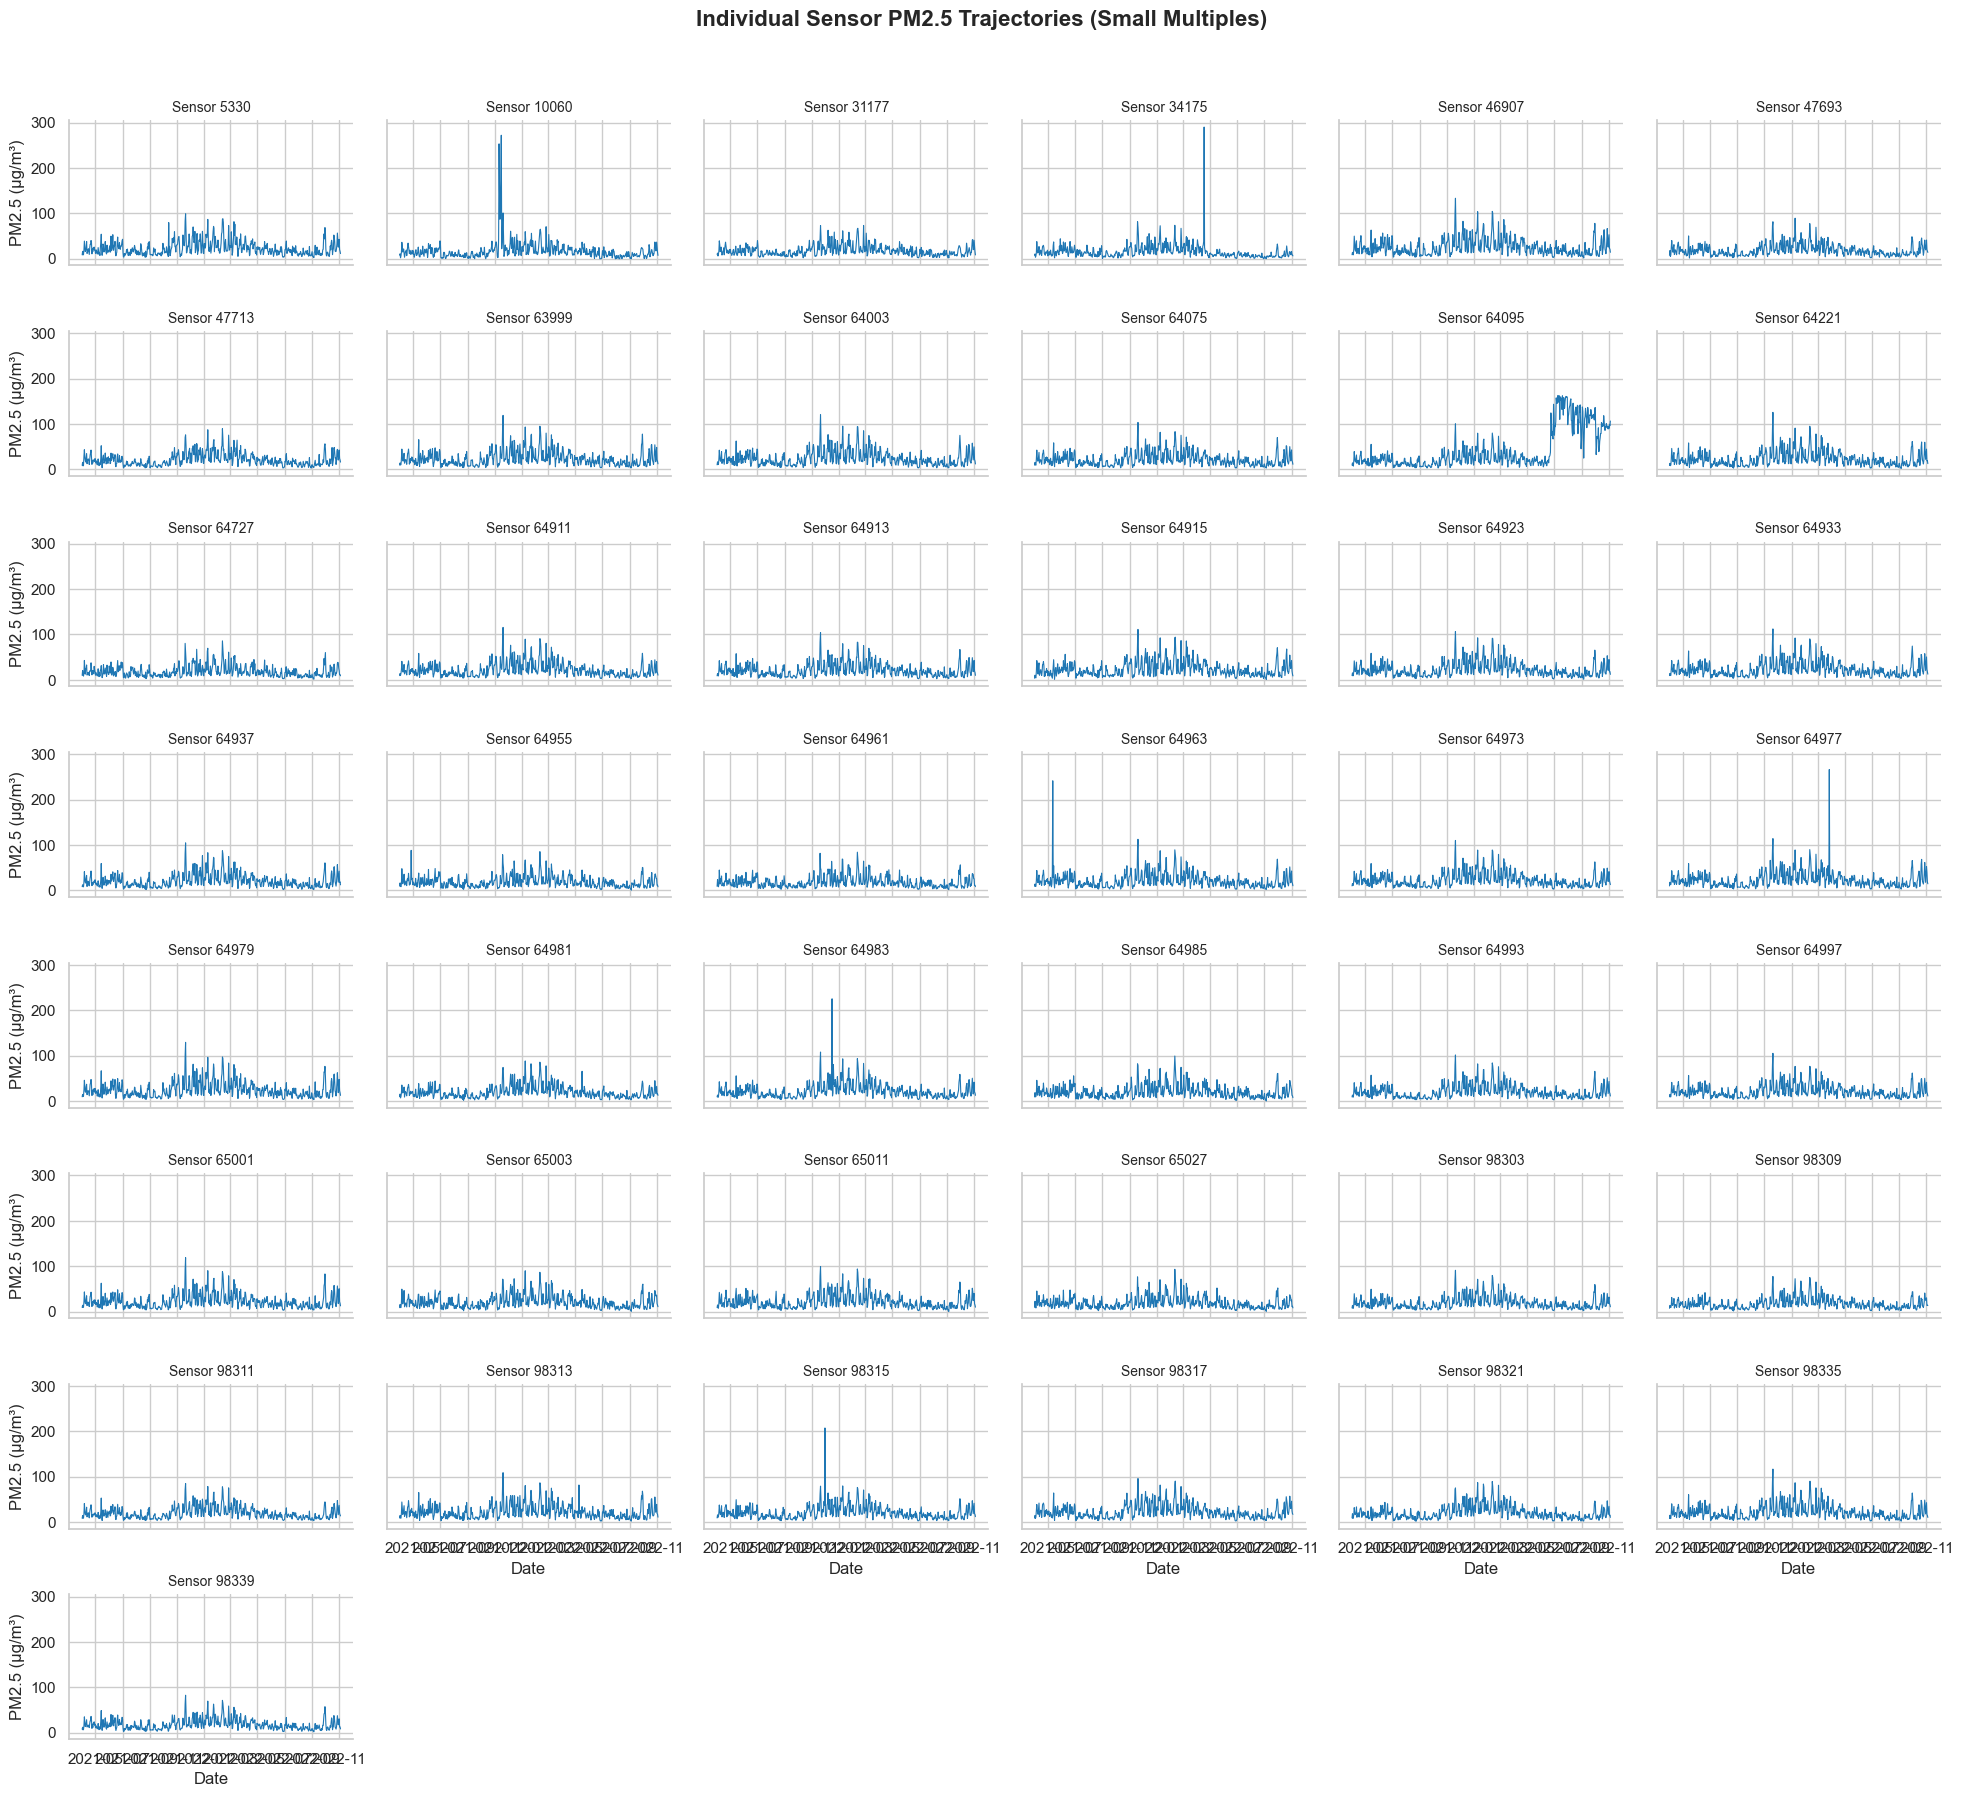

In [82]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df_processed["date"] = pd.to_datetime(df_processed["date"])

# Set up a grid of small line plots (col_wrap=6 means 6 sensors per row)
g = sns.FacetGrid(
    df_processed, 
    col="sensor_index", 
    col_wrap=6, 
    height=2.2, 
    aspect=1.5, 
    sharey=True
)

g.map_dataframe(sns.lineplot, x="date", y="pm25_epa_corrected", color="#1f77b4", linewidth=0.8)

g.set_titles(col_template="Sensor {col_name}", size=10)
g.set_axis_labels("Date", "PM2.5 (µg/m³)")
g.fig.suptitle("Individual Sensor PM2.5 Trajectories (Small Multiples)", fontsize=16, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("korea_pm25_small_multiples.png", dpi=300)
plt.show()

In [ ]:
#using the open street map data 





In [83]:
import geopandas as gpd

# Path to your extracted GeoPackage file
gpkg_path = "south-korea.gpkg"

# 1. Read the correct road layer
roads_gdf = gpd.read_file(gpkg_path, layer="gis_osm_roads_free")

# Filter for major roads for your buffer analysis
major_roads = roads_gdf[
    roads_gdf["fclass"].isin(["motorway", "trunk", "primary"])
]
print(f"Loaded {len(major_roads)} major road segments successfully.")

# 2. (Optional) You can also load land use features using your layer list:
landuse_gdf = gpd.read_file(gpkg_path, layer="gis_osm_landuse_a_free")
print(f"Loaded {len(landuse_gdf)} land use polygons successfully.")

Loaded 78531 major road segments successfully.
Loaded 247016 land use polygons successfully.


In [84]:

# Assuming df_processed is already loaded in your environment
# 1. Extract unique sensor coordinates from your processed dataframe
sensors_unique = (
    df_processed[["sensor_index", "latitude", "longitude"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

# 2. Convert to a GeoDataFrame and project to a metric CRS for South Korea (EPSG: 5179)
sensors_gdf = gpd.GeoDataFrame(
    sensors_unique,
    geometry=gpd.points_from_xy(
        sensors_unique["longitude"], sensors_unique["latitude"]
    ),
    crs="EPSG:4326",
).to_crs(epsg=5179)

# 3. Create a 3km buffer (3000 meters) around each sensor node
buffer_distance = 3000  # meters
sensors_gdf["buffer_geom"] = sensors_gdf.geometry.buffer(buffer_distance)
sensors_buffered = sensors_gdf.set_geometry("buffer_geom")

# 4. Load layers from your GeoPackage
gpkg_path = "south-korea.gpkg"
roads_gdf = gpd.read_file(gpkg_path, layer="gis_osm_roads_free")
landuse_gdf = gpd.read_file(gpkg_path, layer="gis_osm_landuse_a_free")

# Project GIS layers to match the metric CRS
major_roads = (
    roads_gdf[roads_gdf["fclass"].isin(["motorway", "trunk", "primary"])]
    .to_crs(epsg=5179)
)
landuse_proj = landuse_gdf.to_crs(epsg=5179)

# 5. Spatial Joins & Feature Extraction
# Count major roads intersecting each sensor's 3km buffer
road_join = gpd.sjoin(
    major_roads, sensors_buffered, predicate="intersects", how="inner"
)
road_counts = (
    road_join.groupby("sensor_index")
    .size()
    .reset_index(name="major_roads_count_3km")
)

# Calculate total urban/industrial land use area (or percentage) within the buffer if desired
# (Example: filtering for commercial/residential/industrial land use classes)
urban_landuse = landuse_proj[
    landuse_proj["fclass"].isin(["residential", "commercial", "industrial", "retail"])
]
urban_join = gpd.overlay(urban_landuse, sensors_buffered, how="intersection")
urban_join["polygon_area_m2"] = urban_join.geometry.area
urban_area_sum = (
    urban_join.groupby("sensor_index")["polygon_area_m2"]
    .sum()
    .reset_index(name="urban_landuse_area_m2_3km")
)

# Combine static GIS features into a single metadata table per sensor
sensor_gis_features = sensors_unique[["sensor_index"]].merge(
    road_counts, on="sensor_index", how="left"
)
sensor_gis_features = sensor_gis_features.merge(
    urban_area_sum, on="sensor_index", how="left"
).fillna(0)  # Fill missing counts/areas with 0 where no roads/urban areas intersect

# 6. Merge static GIS attributes back into your main time-series df_processed
df_processed_enriched = df_processed.merge(
    sensor_gis_features, on="sensor_index", how="left"
)

print(f"Original shape of df_processed: {df_processed.shape}")
print(f"Enriched shape of df_processed: {df_processed_enriched.shape}")
print(df_processed_enriched.head())

Original shape of df_processed: (25069, 15)
Enriched shape of df_processed: (25069, 17)
   sensor_index       date  pm25_epa_corrected  latitude  longitude  \
0          5330 2021-06-12              30.116  36.80372  126.93623   
1          5330 2021-06-26              20.636  36.80372  126.93623   
2          5330 2021-05-19              29.206  36.80372  126.93623   
3          5330 2021-06-25              21.796  36.80372  126.93623   
4          5330 2021-04-17               9.432  36.80372  126.93623   

   temperature_2m_max  temperature_2m_min  temperature_2m_mean  \
0                28.7                17.7                 21.9   
1                26.0                20.4                 22.2   
2                25.0                10.2                 17.9   
3                27.3                17.9                 22.4   
4                13.4                 5.3                  8.8   

   relative_humidity_2m_mean  precipitation_sum  windgusts_10m_max  \
0                 

In [85]:
df_processed_enriched.head(10)

,sensor_index,date,pm25_epa_corrected,latitude,longitude,temperature_2m_max,temperature_2m_min,temperature_2m_mean,relative_humidity_2m_mean,precipitation_sum,windgusts_10m_max,surface_pressure_mean,et0_fao_evapotranspiration,windspeed_10m_mean,winddirection_10m_prevailing,major_roads_count_3km,urban_landuse_area_m2_3km
0,5330,2021-06-12,30.116,36.80372,126.93623,28.7,17.7,21.9,83,0.0,36.4,1005.7,4.73,5.919843,4.877802,58.0,734199.902239
1,5330,2021-06-26,20.636,36.80372,126.93623,26.0,20.4,22.2,82,4.1,25.6,1004.2,3.28,2.412766,50.944546,58.0,734199.902239
2,5330,2021-05-19,29.206,36.80372,126.93623,25.0,10.2,17.9,69,0.0,27.4,1005.5,4.93,2.605699,342.812818,58.0,734199.902239
3,5330,2021-06-25,21.796,36.80372,126.93623,27.3,17.9,22.4,78,0.2,22.7,1004.8,4.31,2.412209,254.489263,58.0,734199.902239
4,5330,2021-04-17,9.432,36.80372,126.93623,13.4,5.3,8.8,63,0.2,50.0,1009.0,2.90,8.958965,271.374110,58.0,734199.902239
5,5330,2021-05-31,15.832,36.80372,126.93623,24.3,16.2,19.4,74,6.1,37.8,1004.3,3.54,7.765720,207.660283,58.0,734199.902239
6,5330,2021-06-03,14.542,36.80372,126.93623,22.8,16.8,19.3,86,20.3,24.8,998.9,1.37,1.433398,163.936642,58.0,734199.902239
7,5330,2021-05-02,13.646,36.80372,126.93623,16.6,7.8,11.2,71,2.1,37.1,1009.7,3.62,9.783779,316.248067,58.0,734199.902239
8,5330,2021-04-06,38.808,36.80372,126.93623,17.4,5.6,11.0,58,0.0,37.4,1014.4,3.36,5.808721,294.606572,58.0,734199.902239
9,5330,2021-04-08,15.874,36.80372,126.93623,16.0,3.8,10.1,58,0.0,40.7,1012.6,3.74,8.888522,301.978443,58.0,734199.902239


In [86]:


# 1. Load additional layers from your GeoPackage
gpkg_path = "south-korea.gpkg"
buildings_gdf = gpd.read_file(gpkg_path, layer="gis_osm_buildings_a_free").to_crs(epsg=5179)
railways_gdf = gpd.read_file(gpkg_path, layer="gis_osm_railways_free").to_crs(epsg=5179)
landuse_gdf = gpd.read_file(gpkg_path, layer="gis_osm_landuse_a_free").to_crs(epsg=5179)
roads_gdf = gpd.read_file(gpkg_path, layer="gis_osm_roads_free").to_crs(epsg=5179)

# 2. Compute Building Footprint Area (Total building area in m2 per 3km buffer)
building_join = gpd.overlay(buildings_gdf, sensors_buffered, how="intersection")
building_join["building_area_m2"] = building_join.geometry.area
building_area_sum = (
    building_join.groupby("sensor_index")["building_area_m2"]
    .sum()
    .reset_index(name="building_footprint_area_3km")
)

# 3. Compute Forest/Green Space Sinks
forest_landuse = landuse_gdf[landuse_gdf["fclass"].isin(["forest", "wood", "grass", "park"])]
forest_join = gpd.overlay(forest_landuse, sensors_buffered, how="intersection")
forest_join["forest_area_m2"] = forest_join.geometry.area
forest_area_sum = (
    forest_join.groupby("sensor_index")["forest_area_m2"]
    .sum()
    .reset_index(name="green_space_area_3km")
)

# 4. Compute Total Road Length (all street types combined for local traffic density)
road_join = gpd.overlay(roads_gdf, sensors_buffered, how="intersection")
road_join["road_length_m"] = road_join.geometry.length
total_road_length = (
    road_join.groupby("sensor_index")["road_length_m"]
    .sum()
    .reset_index(name="total_road_length_3km")
)

# 5. Compute Railway Proximity/Length
rail_join = gpd.overlay(railways_gdf, sensors_buffered, how="intersection")
rail_join["rail_length_m"] = rail_join.geometry.length
total_rail_length = (
    rail_join.groupby("sensor_index")["rail_length_m"]
    .sum()
    .reset_index(name="railway_length_3km")
)

# 6. Merge all new static GIS features into your master dataset
extra_features = (
    sensor_gis_features  # from your previous major roads / urban script
    .merge(building_area_sum, on="sensor_index", how="left")
    .merge(forest_area_sum, on="sensor_index", how="left")
    .merge(total_road_length, on="sensor_index", how="left")
    .merge(total_rail_length, on="sensor_index", how="left")
    .fillna(0)  # Fill missing values with 0 where features don't exist in buffer
)

# Merge back into df_processed
df_processed_enriched = df_processed.merge(extra_features, on="sensor_index", how="left").fillna(0)

print(f"Final enriched dataset shape: {df_processed_enriched.shape}")
print(df_processed_enriched.columns.tolist())

Final enriched dataset shape: (25069, 21)
['sensor_index', 'date', 'pm25_epa_corrected', 'latitude', 'longitude', 'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'relative_humidity_2m_mean', 'precipitation_sum', 'windgusts_10m_max', 'surface_pressure_mean', 'et0_fao_evapotranspiration', 'windspeed_10m_mean', 'winddirection_10m_prevailing', 'major_roads_count_3km', 'urban_landuse_area_m2_3km', 'building_footprint_area_3km', 'green_space_area_3km', 'total_road_length_3km', 'railway_length_3km']


In [89]:
# 1. Count missing values per column
missing_counts = df_processed_enriched.isnull().sum()
print("Missing values per column:")
print(missing_counts[missing_counts > 0])

# 2. Check if there are any missing values at all in the entire DataFrame
total_missing = df_processed_enriched.isnull().sum().sum()
print(f"\nTotal missing values in dataset: {total_missing}")

Missing values per column:
Series([], dtype: int64)

Total missing values in dataset: 0


In [90]:
df_processed_enriched.head(20)

,sensor_index,date,pm25_epa_corrected,latitude,longitude,temperature_2m_max,temperature_2m_min,temperature_2m_mean,relative_humidity_2m_mean,precipitation_sum,...,surface_pressure_mean,et0_fao_evapotranspiration,windspeed_10m_mean,winddirection_10m_prevailing,major_roads_count_3km,urban_landuse_area_m2_3km,building_footprint_area_3km,green_space_area_3km,total_road_length_3km,railway_length_3km
0,5330,2021-06-12,30.116,36.80372,126.93623,28.7,17.7,21.9,83,0.0,...,1005.7,4.73,5.919843,4.877802,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0
1,5330,2021-06-26,20.636,36.80372,126.93623,26.0,20.4,22.2,82,4.1,...,1004.2,3.28,2.412766,50.944546,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0
2,5330,2021-05-19,29.206,36.80372,126.93623,25.0,10.2,17.9,69,0.0,...,1005.5,4.93,2.605699,342.812818,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0
3,5330,2021-06-25,21.796,36.80372,126.93623,27.3,17.9,22.4,78,0.2,...,1004.8,4.31,2.412209,254.489263,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0
4,5330,2021-04-17,9.432,36.80372,126.93623,13.4,5.3,8.8,63,0.2,...,1009.0,2.90,8.958965,271.374110,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0
5,5330,2021-05-31,15.832,36.80372,126.93623,24.3,16.2,19.4,74,6.1,...,1004.3,3.54,7.765720,207.660283,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0
6,5330,2021-06-03,14.542,36.80372,126.93623,22.8,16.8,19.3,86,20.3,...,998.9,1.37,1.433398,163.936642,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0
7,5330,2021-05-02,13.646,36.80372,126.93623,16.6,7.8,11.2,71,2.1,...,1009.7,3.62,9.783779,316.248067,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0
8,5330,2021-04-06,38.808,36.80372,126.93623,17.4,5.6,11.0,58,0.0,...,1014.4,3.36,5.808721,294.606572,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0
9,5330,2021-04-08,15.874,36.80372,126.93623,16.0,3.8,10.1,58,0.0,...,1012.6,3.74,8.888522,301.978443,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0


In [91]:
import requests

# 1. Extract unique sensor coordinates from your dataset
sensors_unique = (
    df_processed[["sensor_index", "latitude", "longitude"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

# 2. Query Open-Meteo Elevation API in batch
# Open-Meteo accepts comma-separated lists of latitudes and longitudes (up to 100 at a time)
lats = ",".join(sensors_unique["latitude"].astype(str))
lons = ",".join(sensors_unique["longitude"].astype(str))

url = f"https://api.open-meteo.com/v1/elevation?latitude={lats}&longitude={lons}"
response = requests.get(url)
response.raise_for_status()

# 3. Extract elevation results and attach to sensor metadata
elevations = response.json()["elevation"]
sensors_unique["elevation_m"] = elevations

# 4. Merge elevation back into your master df_processed_enriched dataset
df_processed_enriched = df_processed_enriched.merge(
    sensors_unique[["sensor_index", "elevation_m"]], on="sensor_index", how="left"
)

print(f"Added elevation data. Dataset shape: {df_processed_enriched.shape}")
print(df_processed_enriched[["sensor_index", "elevation_m"]].drop_duplicates().head())

Added elevation data. Dataset shape: (25069, 22)
      sensor_index  elevation_m
0             5330         24.0
583          10060         38.0
1166         31177         32.0
1749         34175        119.0
2332         46907         30.0


In [92]:
# 1. Count missing values per column
missing_counts = df_processed_enriched.isnull().sum()
print("Missing values per column:")
print(missing_counts[missing_counts > 0])

# 2. Check if there are any missing values at all in the entire DataFrame
total_missing = df_processed_enriched.isnull().sum().sum()
print(f"\nTotal missing values in dataset: {total_missing}")

Missing values per column:
Series([], dtype: int64)

Total missing values in dataset: 0


In [93]:
df_processed_enriched.head(10)

,sensor_index,date,pm25_epa_corrected,latitude,longitude,temperature_2m_max,temperature_2m_min,temperature_2m_mean,relative_humidity_2m_mean,precipitation_sum,...,et0_fao_evapotranspiration,windspeed_10m_mean,winddirection_10m_prevailing,major_roads_count_3km,urban_landuse_area_m2_3km,building_footprint_area_3km,green_space_area_3km,total_road_length_3km,railway_length_3km,elevation_m
0,5330,2021-06-12,30.116,36.80372,126.93623,28.7,17.7,21.9,83,0.0,...,4.73,5.919843,4.877802,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0
1,5330,2021-06-26,20.636,36.80372,126.93623,26.0,20.4,22.2,82,4.1,...,3.28,2.412766,50.944546,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0
2,5330,2021-05-19,29.206,36.80372,126.93623,25.0,10.2,17.9,69,0.0,...,4.93,2.605699,342.812818,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0
3,5330,2021-06-25,21.796,36.80372,126.93623,27.3,17.9,22.4,78,0.2,...,4.31,2.412209,254.489263,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0
4,5330,2021-04-17,9.432,36.80372,126.93623,13.4,5.3,8.8,63,0.2,...,2.90,8.958965,271.374110,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0
5,5330,2021-05-31,15.832,36.80372,126.93623,24.3,16.2,19.4,74,6.1,...,3.54,7.765720,207.660283,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0
6,5330,2021-06-03,14.542,36.80372,126.93623,22.8,16.8,19.3,86,20.3,...,1.37,1.433398,163.936642,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0
7,5330,2021-05-02,13.646,36.80372,126.93623,16.6,7.8,11.2,71,2.1,...,3.62,9.783779,316.248067,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0
8,5330,2021-04-06,38.808,36.80372,126.93623,17.4,5.6,11.0,58,0.0,...,3.36,5.808721,294.606572,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0
9,5330,2021-04-08,15.874,36.80372,126.93623,16.0,3.8,10.1,58,0.0,...,3.74,8.888522,301.978443,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0


In [94]:
# Extract unique sensors and their elevation values
sensor_elevations = df_processed_enriched[
    ["sensor_index", "elevation_m"]
].drop_duplicates()

# Generate descriptive statistics
elevation_summary = sensor_elevations["elevation_m"].describe()
print(elevation_summary)

count     43.000000
mean      47.906977
std       28.067787
min        8.000000
25%       31.500000
50%       43.000000
75%       54.000000
max      156.000000
Name: elevation_m, dtype: float64


In [95]:
df_processed_enriched['sensor_index'].nunique()

43

In [97]:
with open("analysis_dataset_enriched.p", "wb") as f:
    pickle.dump(df_processed_enriched, f)